In [1]:
!git clone https://github.com/VladWero08/time-series-ad-gan.git

fatal: destination path 'time-series-ad-gan' already exists and is not an empty directory.


In [2]:
pip install pandas numpy kagglehub torch scipy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [3]:
import sys 
import os

module_path = os.path.abspath("./time-series-ad-gan")
if module_path not in sys.path:
    sys.path.append(module_path)

In [ ]:
import ast
import pandas as pd
import numpy as np
import json
import kagglehub
import typing as t
import torch
import matplotlib.pyplot as plt
from urllib.request import urlopen

from src.models.mad_gan import run_pipeline
from src.utils.data import intervals_to_points
from src.utils.errors import point_wise_error, area_wise_error, dtw_error

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Working on {device}!")

Working on cuda!


In [6]:
def plot_signal(X: np.ndarray, y: np.ndarray) -> None:
    plt.figure(figsize=(15, 4))
    for idx in np.where(y == 1)[0]:
        plt.axvline(idx, color='red', alpha=0.4, linewidth=0.8, zorder=0)
    plt.plot(X, zorder=1)
    plt.show()

## **NAB**

In [7]:
NAB_REPO = "https://raw.githubusercontent.com/numenta/NAB/refs/heads/master/data/"

ART_FOLDER = "artificialWithAnomaly/"
ART_FILE_NAMES = [
    "art_daily_flatmiddle",
    "art_daily_jumpsdown",
    "art_daily_jumpsup",
    "art_daily_nojump",
    "art_increase_spike_density",
    "art_load_balancer_spikes"
]

AD_EX_FOLDER = "realAdExchange/"
AD_EX_FILE_NAMES = [
    "exchange-2_cpc_results",
    "exchange-2_cpm_results",
    "exchange-3_cpc_results",
    "exchange-3_cpm_results",
    "exchange-4_cpc_results",
    "exchange-4_cpm_results",
]

AWS_FOLDER = "realAWSCloudwatch/"
AWS_FILE_NAMES = [
    "ec2_cpu_utilization_24ae8d",
    "ec2_cpu_utilization_53ea38",
    "ec2_cpu_utilization_5f5533",
    "ec2_cpu_utilization_77c1ca",
    "ec2_cpu_utilization_825cc2",
    "ec2_cpu_utilization_ac20cd",
    "ec2_cpu_utilization_c6585a",
    "ec2_cpu_utilization_fe7f93",
    "ec2_disk_write_bytes_1ef3de",
    "ec2_disk_write_bytes_c0d644",
    "ec2_network_in_257a54",
    "ec2_network_in_5abac7",
    "elb_request_count_8c0756",
    "grok_asg_anomaly",
    "iio_us-east-1_i-a2eb1cd9_NetworkIn",
    "rds_cpu_utilization_cc0c53",
    "rds_cpu_utilization_e47b3b"
]

TRAFFIC_FOLDER = "realTraffic/"
TRAFFIC_FILE_NAMES = [
    "TravelTime_387",
    "TravelTime_451",
    "occupancy_6005",
    "occupancy_t4013",
    "speed_6005",
    "speed_7578",
    "speed_t4013"
]

TWEETS_FOLDER = "realTweets/"
TWEETS_FILE_NAMES = [
    "Twitter_volume_AAPL",
    "Twitter_volume_AMZN",
    "Twitter_volume_CRM",
    "Twitter_volume_CVS",
    "Twitter_volume_FB",
    "Twitter_volume_GOOG",
    "Twitter_volume_IBM",
    "Twitter_volume_KO",
    "Twitter_volume_PFE",
    "Twitter_volume_UPS"
]

NAB_LABELS = "https://raw.githubusercontent.com/numenta/NAB/refs/heads/master/labels/combined_windows.json"

In [8]:
NAB_HYPERPARAMS = {
    "train_ratio": 0.6,
    "device": device,
    "anomaly_type": "contextual",
    "verbose": True,
    "lr_g": 1e-5,
    "lr_d": 1e-5,
    "epochs": 1000,
    "rec_error_funcs": [("point", point_wise_error), ("area", area_wise_error)],
}

In [9]:
with urlopen(NAB_LABELS) as labels_url:
    nab_labels = json.loads(labels_url.read().decode())

In [10]:
def nab_download_subdataset(folder: str, file_names: list[str], nab_labels: dict) -> t.List[pd.DataFrame]:
    nab_signals = []
    nab_points = 0
    nab_anomalies = 0

    for i, fn in enumerate(file_names):
        # name of the .csv in the repository
        nab_ts_fn = f"{fn}.csv"
        # url to the raw .csv file in the repository
        nab_ts_url = f"{NAB_REPO}{folder}{nab_ts_fn}"

        nab_ts_df = pd.read_csv(nab_ts_url)
        nab_ts_df["is_anomaly"] = 0

        # iterate through the contextualized anomalies for each .csv file,
        # and if the timestamp is inside one of the intervals, toggle the is_anomaly attribute
        for start, end in nab_labels[f"{folder}{nab_ts_fn}"]:
            start = pd.Timestamp(start)
            end = pd.Timestamp(end)
            interval = pd.Interval(start, end, closed="both")

            nab_ts_df.loc[
                nab_ts_df["timestamp"].map(lambda ts: pd.Timestamp(ts) in interval),
                "is_anomaly"
            ] = 1

        nab_signals.append(nab_ts_df)
        nab_points += len(nab_ts_df)
        nab_anomalies += (nab_ts_df["is_anomaly"] == 1).sum()

        if (i + 1) % 5 == 0:
            print(f"Downloaded {i + 1} .csv files.")

    print()
    print(f"Finished downloading {folder}!")
    print("---------------------")
    print(f"Total Signals: {len(file_names)}")
    print(F"Total Points: {nab_points}")
    print(f"Total Anomaly Points: {nab_anomalies}")
    print(f"Anomaly Rate: {(nab_anomalies / nab_points) * 100:.2f}%")

    return nab_signals

### **Artificial with Anomaly**

In [35]:
ART_HYPERPARAMS = NAB_HYPERPARAMS.copy()
ART_HYPERPARAMS["train_ratio"] = 0.5

In [36]:
art_signals = nab_download_subdataset(folder=ART_FOLDER, file_names=ART_FILE_NAMES, nab_labels=nab_labels)

Downloaded 5 .csv files.

Finished downloading artificialWithAnomaly/!
---------------------
Total Signals: 6
Total Points: 24192
Total Anomaly Points: 2418
Anomaly Rate: 10.00%


--------------
Art Signal 1
--------------
Epoch  25 | D Loss: 4.475448 | G Loss: -0.423551
Epoch  50 | D Loss: 2.716197 | G Loss: -0.373977
Epoch  75 | D Loss: 2.485299 | G Loss: -1.087765
Epoch 100 | D Loss: 1.774373 | G Loss: -1.274845
Epoch 125 | D Loss: 0.934465 | G Loss: -0.778479
Epoch 150 | D Loss: 0.475103 | G Loss: -0.473695
Epoch 175 | D Loss: 0.191775 | G Loss: -0.240975
Epoch 200 | D Loss: 0.010201 | G Loss: -0.068471
Epoch 225 | D Loss: 0.180246 | G Loss: -0.229837
Epoch 250 | D Loss: 0.144557 | G Loss: -0.186017
Epoch 275 | D Loss: 0.129720 | G Loss: -0.150446
Epoch 300 | D Loss: 0.084897 | G Loss: -0.112073
Epoch 325 | D Loss: 0.115518 | G Loss: -0.119802
Epoch 350 | D Loss: -0.069554 | G Loss: 0.180063
Epoch 375 | D Loss: 0.086314 | G Loss: 0.148457
Epoch 400 | D Loss: 0.059585 | G Loss: 0.115413
Epoch 425 | D Loss: 0.075237 | G Loss: -0.068792
Epoch 450 | D Loss: 0.089352 | G Loss: 0.004506
Epoch 475 | D Loss: 0.093710 | G Loss: 0.180872
Epoch 500 | D Loss: 0.050098 |

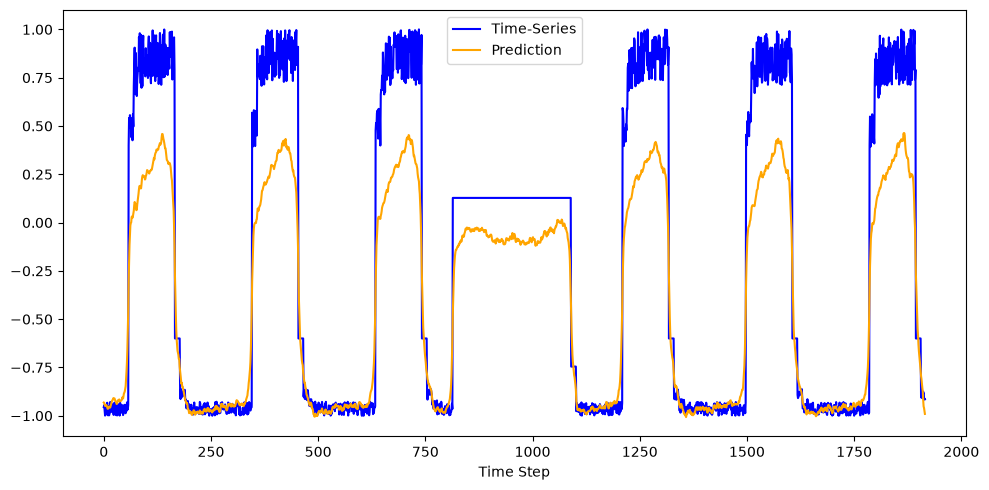

--------------
Art Signal 2
--------------
Epoch  25 | D Loss: 4.732249 | G Loss: 0.008473
Epoch  50 | D Loss: 2.267623 | G Loss: -0.127416
Epoch  75 | D Loss: 1.219854 | G Loss: -0.270264
Epoch 100 | D Loss: 0.028103 | G Loss: 0.171907
Epoch 125 | D Loss: 0.025081 | G Loss: 0.013380
Epoch 150 | D Loss: 0.400271 | G Loss: -0.435202
Epoch 175 | D Loss: 0.344747 | G Loss: -0.357758
Epoch 200 | D Loss: 0.231993 | G Loss: -0.254686
Epoch 225 | D Loss: 0.207149 | G Loss: -0.238154
Epoch 250 | D Loss: 0.206733 | G Loss: -0.258771
Epoch 275 | D Loss: 0.075148 | G Loss: -0.285041
Epoch 300 | D Loss: 0.450719 | G Loss: -0.524861
Epoch 325 | D Loss: -0.724992 | G Loss: 0.030092
Epoch 350 | D Loss: 1.104530 | G Loss: -1.255099
Epoch 375 | D Loss: 0.295760 | G Loss: -0.183241
Epoch 400 | D Loss: 0.208176 | G Loss: -0.077646
Epoch 425 | D Loss: 0.121657 | G Loss: -0.056352
Epoch 450 | D Loss: 0.086663 | G Loss: -0.058980
Epoch 475 | D Loss: 0.073050 | G Loss: -0.057469
Epoch 500 | D Loss: 0.068193 

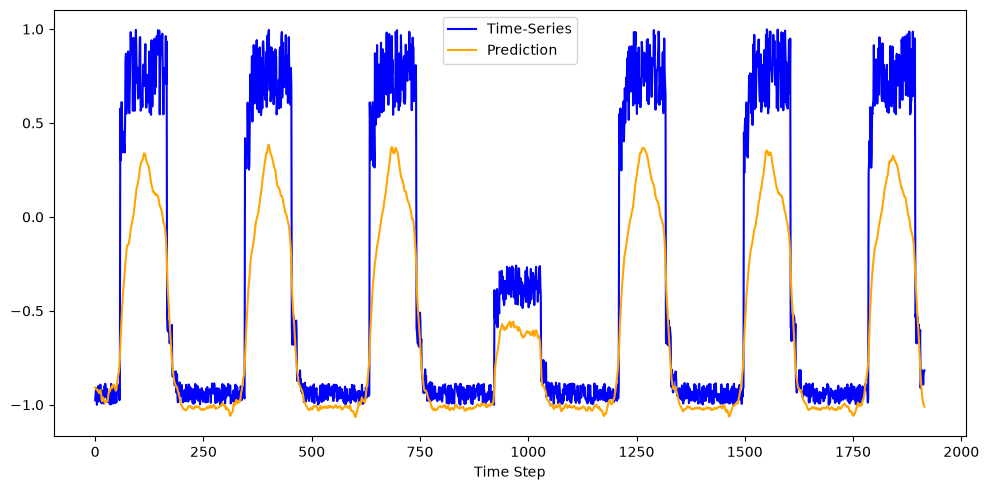

--------------
Art Signal 3
--------------
Epoch  25 | D Loss: 5.150108 | G Loss: -0.144121
Epoch  50 | D Loss: 1.716042 | G Loss: -0.115764
Epoch  75 | D Loss: 0.407171 | G Loss: -0.111269
Epoch 100 | D Loss: 0.147656 | G Loss: -0.195477
Epoch 125 | D Loss: 0.123628 | G Loss: -0.256118
Epoch 150 | D Loss: 0.077533 | G Loss: -0.404181
Epoch 175 | D Loss: 0.237072 | G Loss: -0.465753
Epoch 200 | D Loss: 0.219391 | G Loss: -0.288147
Epoch 225 | D Loss: 0.221321 | G Loss: -0.309139
Epoch 250 | D Loss: 0.152401 | G Loss: -0.223464
Epoch 275 | D Loss: 0.204350 | G Loss: -0.282306
Epoch 300 | D Loss: 0.117906 | G Loss: -0.180933
Epoch 325 | D Loss: 0.075896 | G Loss: -0.177115
Epoch 350 | D Loss: 0.170166 | G Loss: -0.228167
Epoch 375 | D Loss: 0.128655 | G Loss: -0.182687
Epoch 400 | D Loss: 0.172534 | G Loss: -0.230675
Epoch 425 | D Loss: 0.184812 | G Loss: -0.246296
Epoch 450 | D Loss: 0.147601 | G Loss: -0.209852
Epoch 475 | D Loss: 0.117353 | G Loss: -0.160492
Epoch 500 | D Loss: 0.0876

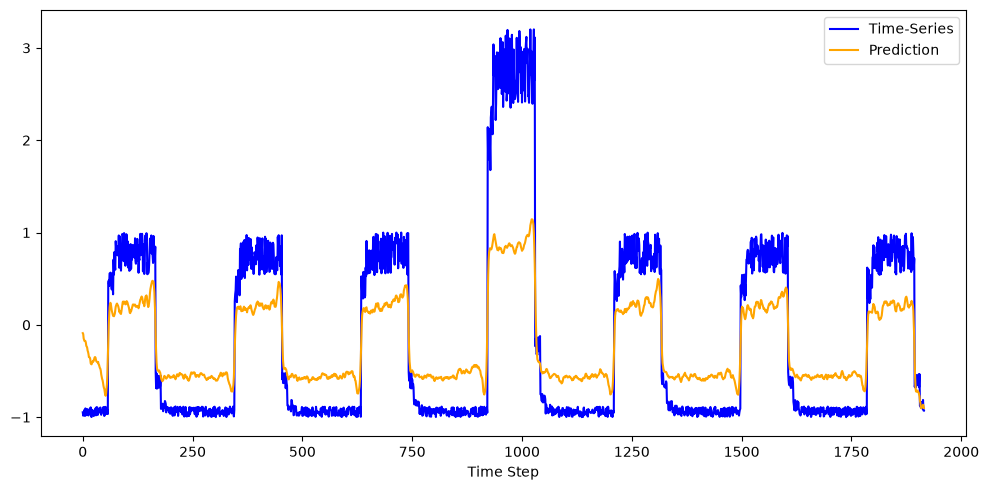

--------------
Art Signal 4
--------------
Epoch  25 | D Loss: 5.659660 | G Loss: -0.110097
Epoch  50 | D Loss: 2.714336 | G Loss: 0.111634
Epoch  75 | D Loss: 1.509608 | G Loss: -0.723451
Epoch 100 | D Loss: 0.597767 | G Loss: -0.373831
Epoch 125 | D Loss: 0.288692 | G Loss: -0.303002
Epoch 150 | D Loss: 0.232796 | G Loss: -0.256256
Epoch 175 | D Loss: 0.208505 | G Loss: -0.239991
Epoch 200 | D Loss: 0.386422 | G Loss: -0.387850
Epoch 225 | D Loss: 0.230013 | G Loss: -0.227584
Epoch 250 | D Loss: 0.262406 | G Loss: -0.265150
Epoch 275 | D Loss: 0.172270 | G Loss: -0.183085
Epoch 300 | D Loss: 0.112103 | G Loss: -0.116747
Epoch 325 | D Loss: 0.056078 | G Loss: -0.086093
Epoch 350 | D Loss: 0.087162 | G Loss: -0.061326
Epoch 375 | D Loss: 0.126446 | G Loss: -0.124538
Epoch 400 | D Loss: 0.095928 | G Loss: -0.115264
Epoch 425 | D Loss: 0.054723 | G Loss: 0.254713
Epoch 450 | D Loss: 0.068995 | G Loss: 0.171192
Epoch 475 | D Loss: 0.093788 | G Loss: 0.117022
Epoch 500 | D Loss: 0.070841 |

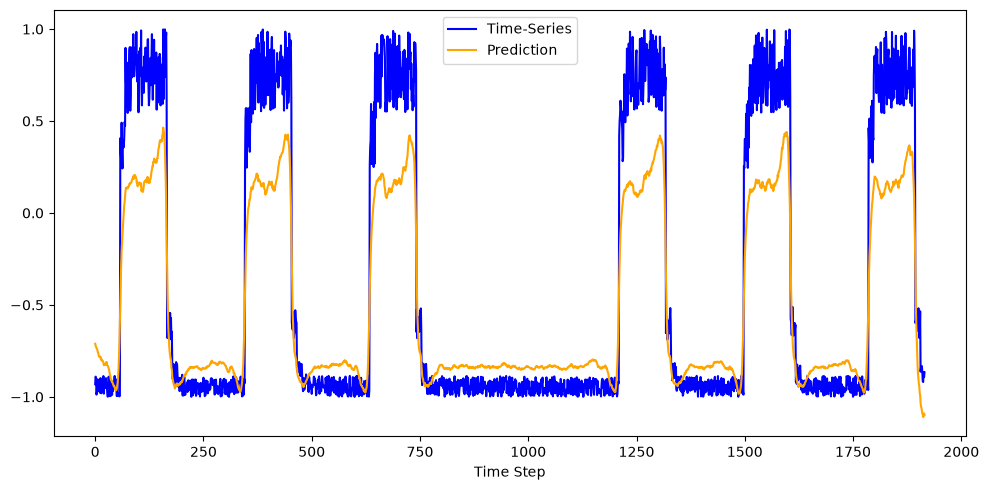

--------------
Art Signal 5
--------------
Epoch  25 | D Loss: 4.316055 | G Loss: -0.043053
Epoch  50 | D Loss: 2.781336 | G Loss: -0.484155
Epoch  75 | D Loss: 1.308524 | G Loss: -0.265299
Epoch 100 | D Loss: 0.339009 | G Loss: 0.048196
Epoch 125 | D Loss: 0.153251 | G Loss: -0.016758
Epoch 150 | D Loss: 0.125963 | G Loss: 0.036512
Epoch 175 | D Loss: -0.010182 | G Loss: 0.396384
Epoch 200 | D Loss: 0.057314 | G Loss: 0.255906
Epoch 225 | D Loss: 0.101081 | G Loss: 0.136312
Epoch 250 | D Loss: 0.083982 | G Loss: 0.218039
Epoch 275 | D Loss: 0.074775 | G Loss: 0.217232
Epoch 300 | D Loss: 0.063680 | G Loss: 0.277593
Epoch 325 | D Loss: 0.092050 | G Loss: 0.296079
Epoch 350 | D Loss: 0.087677 | G Loss: 0.307608
Epoch 375 | D Loss: 0.075748 | G Loss: 0.396718
Epoch 400 | D Loss: 0.049715 | G Loss: 0.486085
Epoch 425 | D Loss: 0.018423 | G Loss: 0.570410
Epoch 450 | D Loss: -0.001897 | G Loss: 0.202100
Epoch 475 | D Loss: -0.033753 | G Loss: 0.320231
Epoch 500 | D Loss: -0.053501 | G Loss

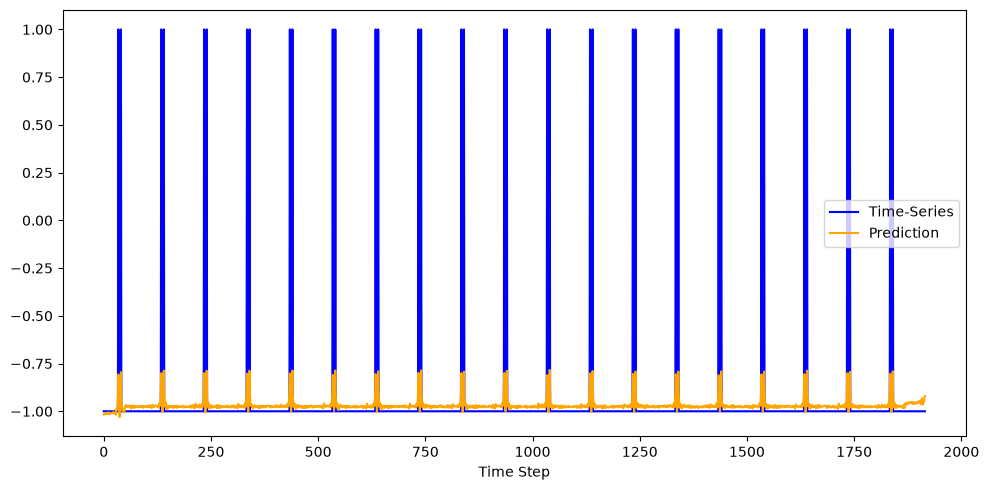

--------------
Art Signal 6
--------------
Epoch  25 | D Loss: 3.981409 | G Loss: -0.434611
Epoch  50 | D Loss: 2.019755 | G Loss: 0.014570
Epoch  75 | D Loss: 2.086008 | G Loss: -1.124370
Epoch 100 | D Loss: 0.993725 | G Loss: -0.700447
Epoch 125 | D Loss: 0.536300 | G Loss: -0.780623
Epoch 150 | D Loss: 1.740182 | G Loss: -1.754736
Epoch 175 | D Loss: 1.938378 | G Loss: -1.862759
Epoch 200 | D Loss: 2.034559 | G Loss: -1.904557
Epoch 225 | D Loss: 1.834847 | G Loss: -1.699501
Epoch 250 | D Loss: 1.466959 | G Loss: -1.393422
Epoch 275 | D Loss: 1.100101 | G Loss: -1.076316
Epoch 300 | D Loss: 0.608839 | G Loss: -0.569822
Epoch 325 | D Loss: 0.315242 | G Loss: -0.365996
Epoch 350 | D Loss: 0.192721 | G Loss: -0.267199
Epoch 375 | D Loss: 0.288425 | G Loss: -0.324850
Epoch 400 | D Loss: 0.219473 | G Loss: -0.249023
Epoch 425 | D Loss: 0.251439 | G Loss: -0.268148
Epoch 450 | D Loss: 0.229517 | G Loss: -0.196253
Epoch 475 | D Loss: 0.248977 | G Loss: -0.250580
Epoch 500 | D Loss: 0.21975

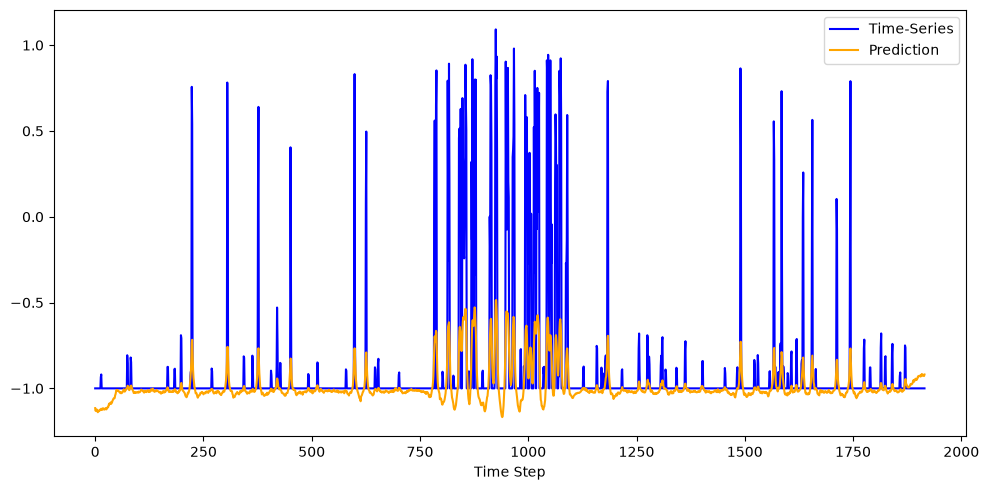

------------------
Art Signal Metrics
------------------
[point] Precision: 0.181 | Recall: 0.500 | F1: 0.261
[area] Precision: 0.347 | Recall: 0.833 | F1: 0.450


In [37]:
total_metrics = {name: np.zeros(3) for (name, _) in ART_HYPERPARAMS["rec_error_funcs"]}

for i, art_signal in enumerate(art_signals):
    X = art_signal["value"].to_numpy()
    # expand from shape (T, ) to (T, 1)  
    X = np.expand_dims(X, axis=1)
    y = art_signal["is_anomaly"].to_numpy()
    
    print("--------------")
    print(f"Art Signal {i + 1}")
    print("--------------")

    metrics = run_pipeline(X, y, **ART_HYPERPARAMS)

    for key in total_metrics:
        total_metrics[key] += np.array(metrics[key])

print("------------------")
print("Art Signal Metrics")
print("------------------")

for key in total_metrics:
    total_metrics[key] = total_metrics[key] / len(art_signals)
    print(f"[{key}] Precision: {total_metrics[key][0]:.3f} | Recall: {total_metrics[key][1]:.3f} | F1: {total_metrics[key][2]:.3f}")

### **Ad Exchange**

In [42]:
ad_ex_signals = nab_download_subdataset(folder=AD_EX_FOLDER, file_names=AD_EX_FILE_NAMES, nab_labels=nab_labels)

Downloaded 5 .csv files.

Finished downloading realAdExchange/!
---------------------
Total Signals: 6
Total Points: 9610
Total Anomaly Points: 960
Anomaly Rate: 9.99%


--------------
Ad Exchange Signal 1
--------------
Epoch  25 | D Loss: 6.413362 | G Loss: -0.110545
Epoch  50 | D Loss: 5.052379 | G Loss: -0.100271
Epoch  75 | D Loss: 3.836242 | G Loss: -0.074627
Epoch 100 | D Loss: 2.602812 | G Loss: -0.032703
Epoch 125 | D Loss: 1.527775 | G Loss: -0.021279
Epoch 150 | D Loss: 0.670894 | G Loss: -0.362108
Epoch 175 | D Loss: 0.805937 | G Loss: -0.695004
Epoch 200 | D Loss: 0.375447 | G Loss: -0.405062
Epoch 225 | D Loss: 0.241469 | G Loss: -0.328465
Epoch 250 | D Loss: 0.095753 | G Loss: -0.168446
Epoch 275 | D Loss: -0.402478 | G Loss: 0.405888
Epoch 300 | D Loss: -0.618792 | G Loss: 0.672623
Epoch 325 | D Loss: -0.376638 | G Loss: 0.458794
Epoch 350 | D Loss: 0.217314 | G Loss: -0.161134
Epoch 375 | D Loss: 0.509311 | G Loss: -0.511269
Epoch 400 | D Loss: 0.650946 | G Loss: -0.605472
Epoch 425 | D Loss: 0.376129 | G Loss: -0.315558
Epoch 450 | D Loss: 0.157213 | G Loss: -0.115576
Epoch 475 | D Loss: 0.043115 | G Loss: -0.031247
Epoch 500 | D Loss

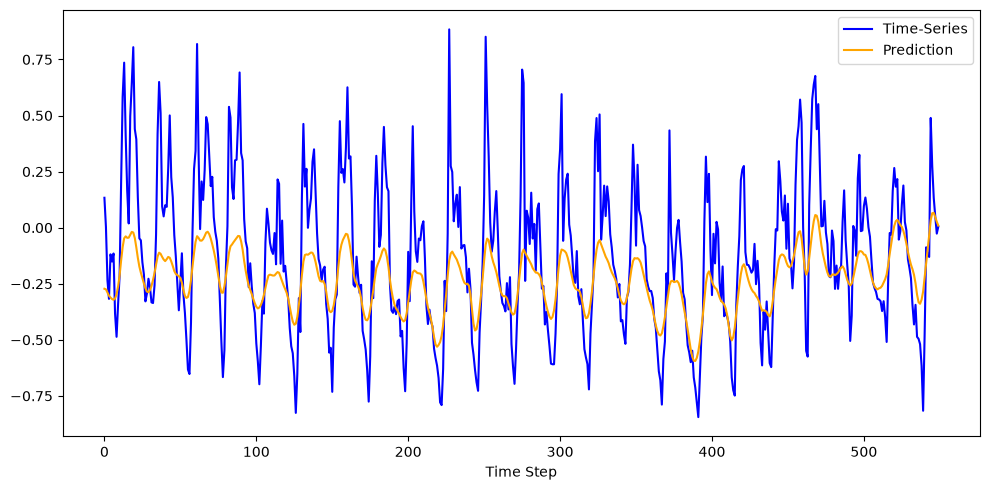

--------------
Ad Exchange Signal 2
--------------
Epoch  25 | D Loss: 7.017158 | G Loss: -0.074622
Epoch  50 | D Loss: 5.521352 | G Loss: -0.154447
Epoch  75 | D Loss: 3.484714 | G Loss: 0.107035
Epoch 100 | D Loss: 2.521970 | G Loss: 0.021098
Epoch 125 | D Loss: 1.436599 | G Loss: -0.032508
Epoch 150 | D Loss: 0.660997 | G Loss: -0.072545
Epoch 175 | D Loss: 0.249885 | G Loss: -0.144807
Epoch 200 | D Loss: 1.050530 | G Loss: -0.731718
Epoch 225 | D Loss: 2.021649 | G Loss: -1.675487
Epoch 250 | D Loss: 1.959566 | G Loss: -1.760254
Epoch 275 | D Loss: 7.976655 | G Loss: -7.352853
Epoch 300 | D Loss: 8.511476 | G Loss: -6.967775
Epoch 325 | D Loss: 7.926618 | G Loss: -5.567696
Epoch 350 | D Loss: 6.862875 | G Loss: -4.061766
Epoch 375 | D Loss: 5.464006 | G Loss: -2.557986
Epoch 400 | D Loss: 3.878575 | G Loss: -1.164578
Epoch 425 | D Loss: 3.026862 | G Loss: -1.064306
Epoch 450 | D Loss: 2.283604 | G Loss: -0.898772
Epoch 475 | D Loss: 1.772849 | G Loss: -0.740489
Epoch 500 | D Loss: 

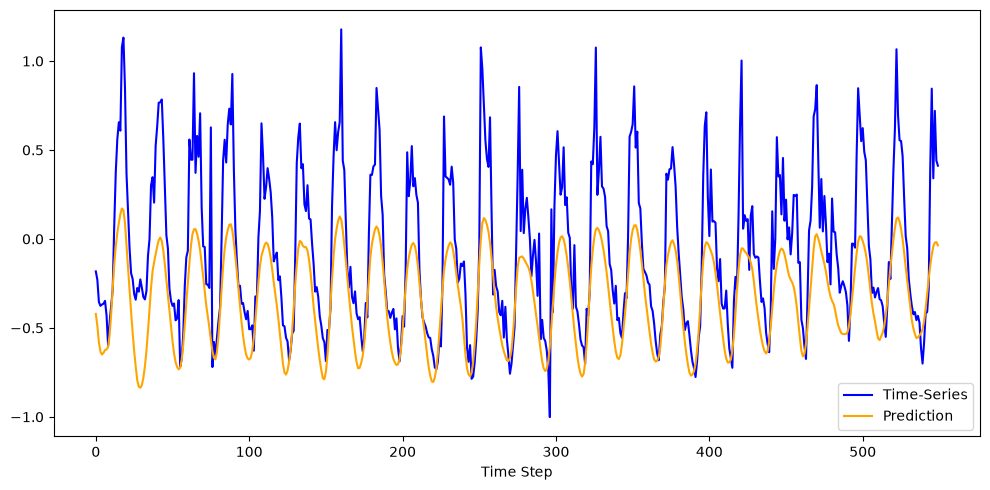

--------------
Ad Exchange Signal 3
--------------
Epoch  25 | D Loss: 4.294478 | G Loss: -0.012002
Epoch  50 | D Loss: 4.357766 | G Loss: -0.774933
Epoch  75 | D Loss: 4.870593 | G Loss: -1.648880
Epoch 100 | D Loss: 3.582171 | G Loss: -0.850381
Epoch 125 | D Loss: 3.784998 | G Loss: -1.477417
Epoch 150 | D Loss: 2.969429 | G Loss: -1.173453
Epoch 175 | D Loss: 2.319483 | G Loss: -0.888133
Epoch 200 | D Loss: 1.532850 | G Loss: -0.404894
Epoch 225 | D Loss: 0.932308 | G Loss: -0.131185
Epoch 250 | D Loss: 0.588773 | G Loss: -0.050772
Epoch 275 | D Loss: 0.363761 | G Loss: -0.016034
Epoch 300 | D Loss: 0.224659 | G Loss: 0.000633
Epoch 325 | D Loss: 0.139425 | G Loss: 0.053929
Epoch 350 | D Loss: -0.133610 | G Loss: 0.406342
Epoch 375 | D Loss: -0.802273 | G Loss: 1.328951
Epoch 400 | D Loss: -0.374641 | G Loss: 1.044623
Epoch 425 | D Loss: 0.024754 | G Loss: 0.565177
Epoch 450 | D Loss: 0.069544 | G Loss: 0.401537
Epoch 475 | D Loss: 0.072076 | G Loss: 0.307795
Epoch 500 | D Loss: 0.0

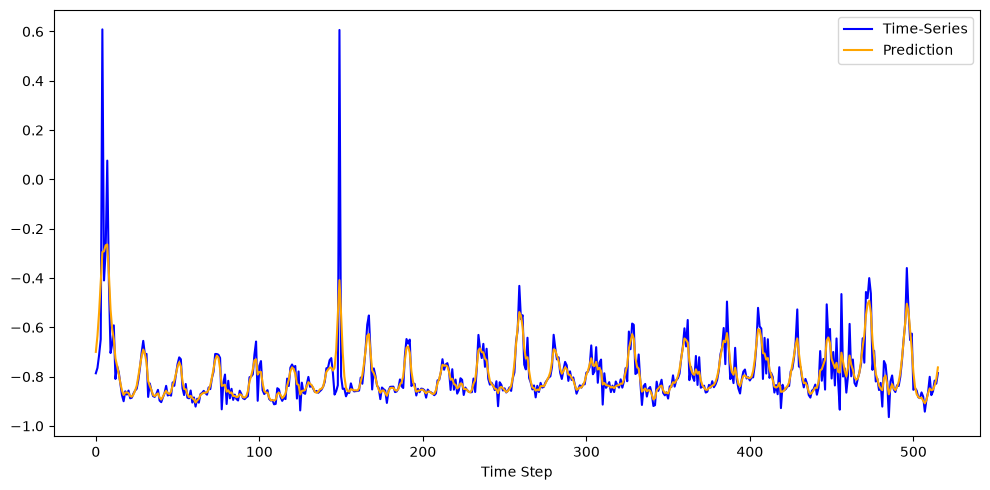

--------------
Ad Exchange Signal 4
--------------
Epoch  25 | D Loss: 6.613351 | G Loss: -0.062175
Epoch  50 | D Loss: 5.677497 | G Loss: -0.136123
Epoch  75 | D Loss: 4.710619 | G Loss: -0.235401
Epoch 100 | D Loss: 3.838414 | G Loss: -0.162431
Epoch 125 | D Loss: 3.147194 | G Loss: -0.193755
Epoch 150 | D Loss: 2.845146 | G Loss: -0.458463
Epoch 175 | D Loss: 2.609802 | G Loss: -0.650513
Epoch 200 | D Loss: 2.073952 | G Loss: -0.492010
Epoch 225 | D Loss: 1.936247 | G Loss: -0.645084
Epoch 250 | D Loss: 1.658461 | G Loss: -0.623820
Epoch 275 | D Loss: 1.387470 | G Loss: -0.554683
Epoch 300 | D Loss: 1.151773 | G Loss: -0.438730
Epoch 325 | D Loss: 0.888534 | G Loss: -0.234708
Epoch 350 | D Loss: 0.507743 | G Loss: 0.131585
Epoch 375 | D Loss: 0.297880 | G Loss: 0.290376
Epoch 400 | D Loss: 0.278885 | G Loss: 0.119674
Epoch 425 | D Loss: -0.029898 | G Loss: 0.232593
Epoch 450 | D Loss: -0.303474 | G Loss: 0.337763
Epoch 475 | D Loss: -0.303568 | G Loss: 0.229679
Epoch 500 | D Loss: 0

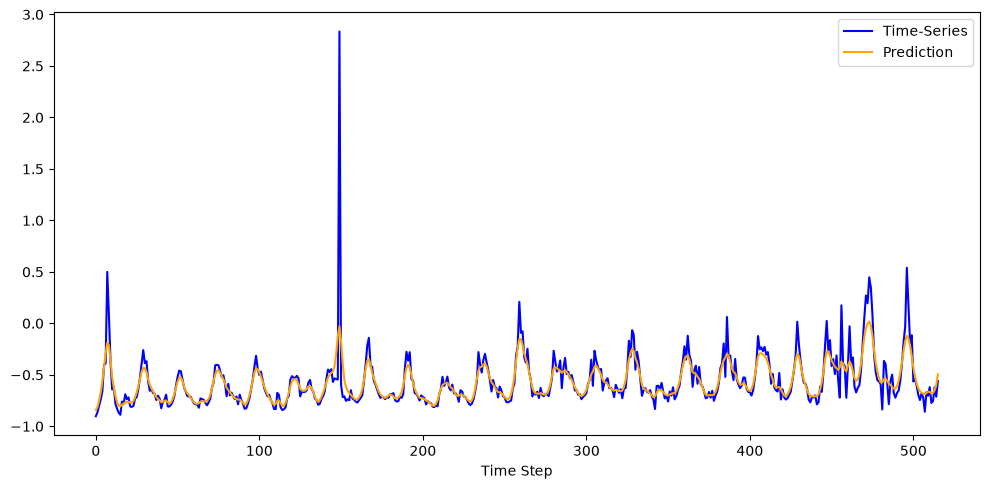

--------------
Ad Exchange Signal 5
--------------
Epoch  25 | D Loss: 4.736921 | G Loss: -0.084214
Epoch  50 | D Loss: 3.671690 | G Loss: -0.077910
Epoch  75 | D Loss: 2.630240 | G Loss: -0.073887
Epoch 100 | D Loss: 1.837443 | G Loss: -0.093583
Epoch 125 | D Loss: 1.154067 | G Loss: -0.126255
Epoch 150 | D Loss: 0.862257 | G Loss: -0.313462
Epoch 175 | D Loss: 0.770478 | G Loss: -0.409096
Epoch 200 | D Loss: 0.353269 | G Loss: -0.236959
Epoch 225 | D Loss: 0.382802 | G Loss: -0.349392
Epoch 250 | D Loss: 0.418146 | G Loss: -0.394722
Epoch 275 | D Loss: 0.391581 | G Loss: -0.356297
Epoch 300 | D Loss: 0.327184 | G Loss: -0.263002
Epoch 325 | D Loss: 0.248083 | G Loss: -0.136198
Epoch 350 | D Loss: 0.124511 | G Loss: 0.056362
Epoch 375 | D Loss: 0.000532 | G Loss: 0.249341
Epoch 400 | D Loss: -0.020859 | G Loss: 0.282065
Epoch 425 | D Loss: 0.136448 | G Loss: 0.068184
Epoch 450 | D Loss: 0.186076 | G Loss: -0.058811
Epoch 475 | D Loss: 0.183213 | G Loss: -0.123853
Epoch 500 | D Loss: 0

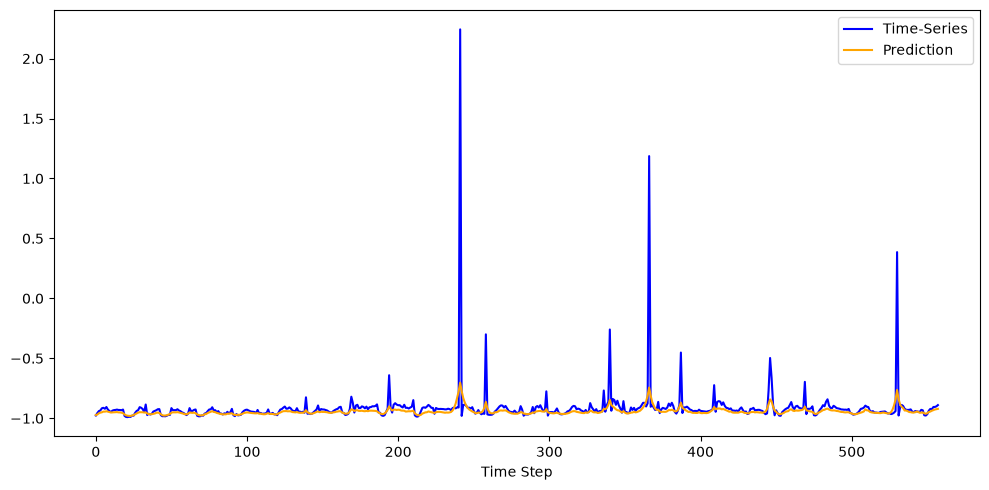

--------------
Ad Exchange Signal 6
--------------
Epoch  25 | D Loss: 6.863008 | G Loss: -0.103491
Epoch  50 | D Loss: 6.522848 | G Loss: -1.242394
Epoch  75 | D Loss: 5.916465 | G Loss: -1.032664
Epoch 100 | D Loss: 2.734471 | G Loss: 1.620509
Epoch 125 | D Loss: 0.203269 | G Loss: 3.571220
Epoch 150 | D Loss: -0.201944 | G Loss: 3.599889
Epoch 175 | D Loss: 1.514318 | G Loss: 1.700995
Epoch 200 | D Loss: 3.676440 | G Loss: -0.607729
Epoch 225 | D Loss: 4.505846 | G Loss: -1.786159
Epoch 250 | D Loss: 4.594977 | G Loss: -2.541984
Epoch 275 | D Loss: 4.405452 | G Loss: -2.996362
Epoch 300 | D Loss: 4.272240 | G Loss: -3.442447
Epoch 325 | D Loss: 4.040925 | G Loss: -3.632654
Epoch 350 | D Loss: 4.015479 | G Loss: -3.854067
Epoch 375 | D Loss: 4.362344 | G Loss: -4.241741
Epoch 400 | D Loss: 4.181777 | G Loss: -3.824371
Epoch 425 | D Loss: 3.522815 | G Loss: -2.901930
Epoch 450 | D Loss: 2.807766 | G Loss: -2.066384
Epoch 475 | D Loss: 2.117240 | G Loss: -1.360724
Epoch 500 | D Loss: 1

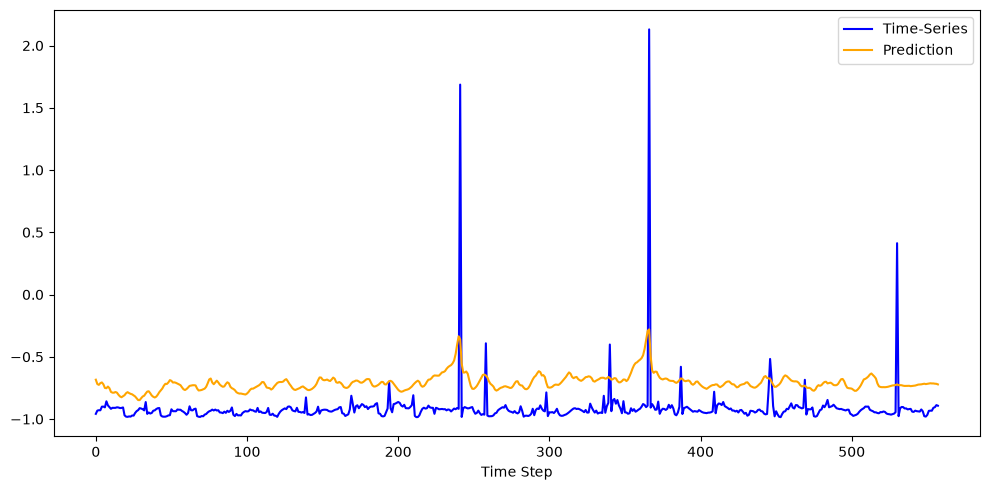

------------------
Ad Exchange Metrics
------------------
[point] Precision: 0.333 | Recall: 0.333 | F1: 0.333
[area] Precision: 0.333 | Recall: 0.333 | F1: 0.333


In [43]:
total_metrics = {name: np.zeros(3) for (name, _) in NAB_HYPERPARAMS["rec_error_funcs"]}

for i, ad_ex_signal in enumerate(ad_ex_signals):
    X = ad_ex_signal['value'].to_numpy()
    # expand from shape (T, ) to (T, 1)  
    X = np.expand_dims(X, axis=1)
    # min-max normalization to [-1, 1]
    y = ad_ex_signal['is_anomaly'].to_numpy()
    
    print("--------------")
    print(f"Ad Exchange Signal {i + 1}")
    print("--------------")

    metrics = run_pipeline(X, y, **NAB_HYPERPARAMS)

    for key in total_metrics:
        total_metrics[key] += np.array(metrics[key])

print("------------------")
print("Ad Exchange Metrics")
print("------------------")

for key in total_metrics:
    total_metrics[key] = total_metrics[key] / len(ad_ex_signals)
    print(f"[{key}] Precision: {total_metrics[key][0]:.3f} | Recall: {total_metrics[key][1]:.3f} | F1: {total_metrics[key][2]:.3f}")

### **AWS Cloudwatch**

In [38]:
aws_signals = nab_download_subdataset(folder=AWS_FOLDER, file_names=AWS_FILE_NAMES, nab_labels=nab_labels)

Downloaded 5 .csv files.
Downloaded 10 .csv files.
Downloaded 15 .csv files.

Finished downloading realAWSCloudwatch/!
---------------------
Total Signals: 17
Total Points: 67740
Total Anomaly Points: 6312
Anomaly Rate: 9.32%


--------------
AWS Signal 1
--------------
Epoch  25 | D Loss: 4.491017 | G Loss: 0.021524
Epoch  50 | D Loss: 3.543942 | G Loss: -1.027765
Epoch  75 | D Loss: 1.632805 | G Loss: -0.512581
Epoch 100 | D Loss: 0.090283 | G Loss: -0.036071
Epoch 125 | D Loss: -1.217984 | G Loss: 1.003980
Epoch 150 | D Loss: 0.676347 | G Loss: -0.814796
Epoch 175 | D Loss: 0.394298 | G Loss: -0.383403
Epoch 200 | D Loss: 0.259328 | G Loss: -0.209089
Epoch 225 | D Loss: 0.184303 | G Loss: -0.082213
Epoch 250 | D Loss: 0.066730 | G Loss: -0.001283
Epoch 275 | D Loss: 0.100869 | G Loss: -0.072340
Epoch 300 | D Loss: 0.001074 | G Loss: 0.027590
Epoch 325 | D Loss: 0.038369 | G Loss: -0.276449
Epoch 350 | D Loss: 0.098932 | G Loss: -0.118856
Epoch 375 | D Loss: 0.112039 | G Loss: -0.186181
Epoch 400 | D Loss: 0.149742 | G Loss: -0.309676
Epoch 425 | D Loss: 0.134872 | G Loss: -0.446667
Epoch 450 | D Loss: 0.136271 | G Loss: -0.489961
Epoch 475 | D Loss: 0.116211 | G Loss: -0.561082
Epoch 500 | D Loss: 0.085099

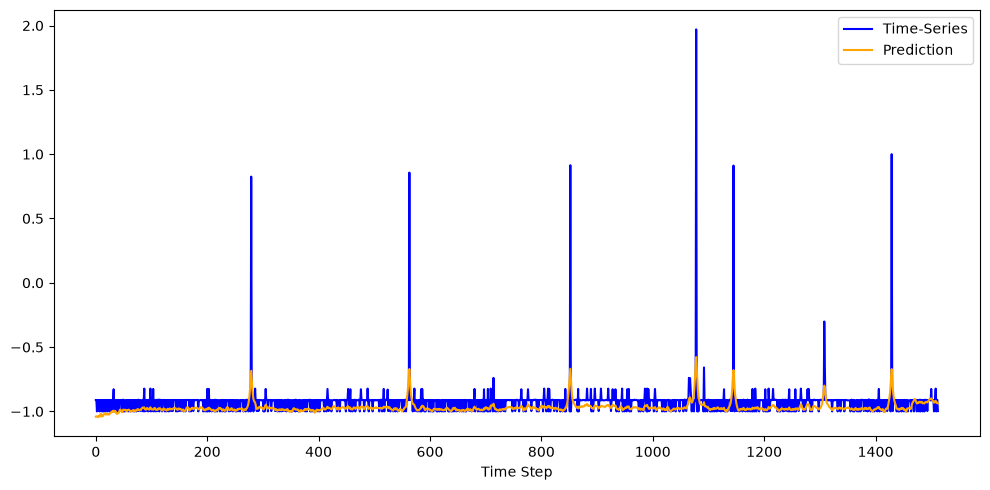

--------------
AWS Signal 2
--------------
Epoch  25 | D Loss: 5.009182 | G Loss: -0.359724
Epoch  50 | D Loss: 1.570816 | G Loss: 0.162359
Epoch  75 | D Loss: 0.190060 | G Loss: 0.023525
Epoch 100 | D Loss: -0.005182 | G Loss: 0.227974
Epoch 125 | D Loss: 0.166484 | G Loss: -0.215245
Epoch 150 | D Loss: 0.404616 | G Loss: -0.373746
Epoch 175 | D Loss: 0.042112 | G Loss: 0.018876
Epoch 200 | D Loss: 0.004534 | G Loss: 0.056316
Epoch 225 | D Loss: 0.010754 | G Loss: 0.059933
Epoch 250 | D Loss: 0.019433 | G Loss: 0.058046
Epoch 275 | D Loss: 0.015322 | G Loss: 0.077202
Epoch 300 | D Loss: -0.011804 | G Loss: 0.097365
Epoch 325 | D Loss: 0.055709 | G Loss: 0.021528
Epoch 350 | D Loss: 0.028837 | G Loss: 0.030699
Epoch 375 | D Loss: 0.031832 | G Loss: 0.014750
Epoch 400 | D Loss: 0.040109 | G Loss: -0.011792
Epoch 425 | D Loss: 0.036935 | G Loss: -0.025221
Epoch 450 | D Loss: 0.032606 | G Loss: -0.025179
Epoch 475 | D Loss: 0.022192 | G Loss: -0.036963
Epoch 500 | D Loss: 0.008420 | G Los

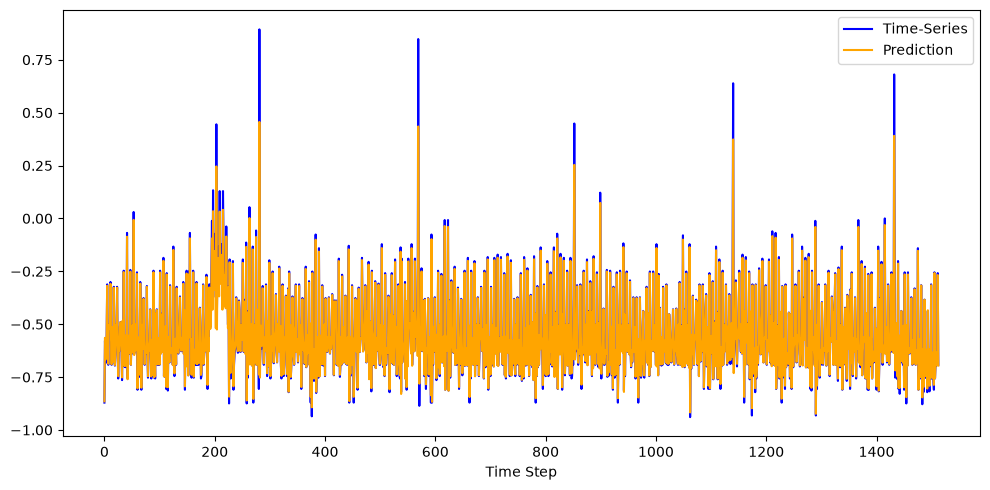

--------------
AWS Signal 3
--------------
Epoch  25 | D Loss: 3.883757 | G Loss: 0.000235
Epoch  50 | D Loss: 4.438234 | G Loss: -2.813502
Epoch  75 | D Loss: 3.200450 | G Loss: -1.970646
Epoch 100 | D Loss: 0.620484 | G Loss: 0.045339
Epoch 125 | D Loss: -0.039211 | G Loss: 0.235374
Epoch 150 | D Loss: -0.087993 | G Loss: 0.188495
Epoch 175 | D Loss: -0.038150 | G Loss: 0.151582
Epoch 200 | D Loss: 0.033506 | G Loss: 0.061381
Epoch 225 | D Loss: 0.002553 | G Loss: 0.067390
Epoch 250 | D Loss: 0.015655 | G Loss: 0.055065
Epoch 275 | D Loss: 0.054186 | G Loss: -0.000913
Epoch 300 | D Loss: 0.095220 | G Loss: -0.072677
Epoch 325 | D Loss: 0.104445 | G Loss: -0.117969
Epoch 350 | D Loss: 0.084773 | G Loss: -0.140601
Epoch 375 | D Loss: 0.014377 | G Loss: -0.083703
Epoch 400 | D Loss: -0.097652 | G Loss: -0.147015
Epoch 425 | D Loss: -0.238642 | G Loss: -0.163761
Epoch 450 | D Loss: 1.036623 | G Loss: -1.423319
Epoch 475 | D Loss: 1.049035 | G Loss: -1.255442
Epoch 500 | D Loss: 0.788341 

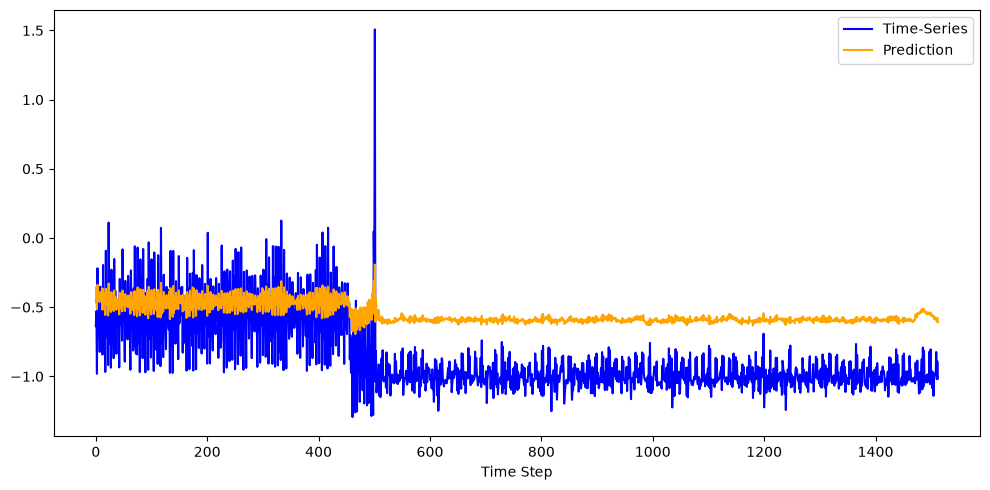

--------------
AWS Signal 4
--------------
Epoch  25 | D Loss: 2.756979 | G Loss: 0.203436
Epoch  50 | D Loss: 0.244495 | G Loss: 0.174689
Epoch  75 | D Loss: 0.027293 | G Loss: 0.167652
Epoch 100 | D Loss: 0.049423 | G Loss: 0.135053
Epoch 125 | D Loss: 0.063531 | G Loss: 0.122431
Epoch 150 | D Loss: 0.127657 | G Loss: 0.086136
Epoch 175 | D Loss: 0.134727 | G Loss: 0.201686
Epoch 200 | D Loss: 0.065472 | G Loss: 0.576366
Epoch 225 | D Loss: 0.306011 | G Loss: 0.042833
Epoch 250 | D Loss: 0.931769 | G Loss: -0.540770
Epoch 275 | D Loss: 0.710436 | G Loss: 0.348305
Epoch 300 | D Loss: 0.176644 | G Loss: 0.382497
Epoch 325 | D Loss: 0.017676 | G Loss: 0.907434
Epoch 350 | D Loss: 0.000964 | G Loss: 1.043582
Epoch 375 | D Loss: -0.000970 | G Loss: 1.079229
Epoch 400 | D Loss: -0.007391 | G Loss: 1.119083
Epoch 425 | D Loss: -0.006443 | G Loss: 1.248299
Epoch 450 | D Loss: -0.037283 | G Loss: 1.612502
Epoch 475 | D Loss: -0.233265 | G Loss: 1.577877
Epoch 500 | D Loss: -5.578478 | G Loss:

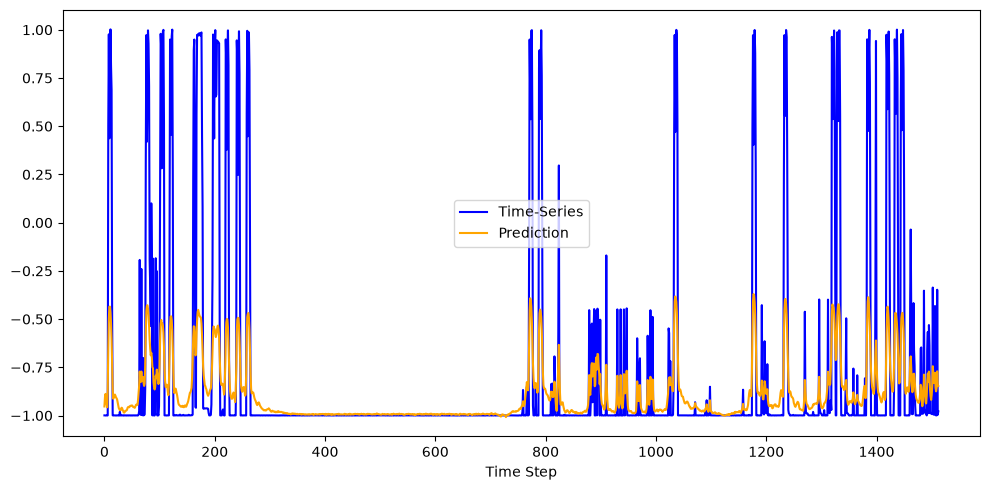

--------------
AWS Signal 5
--------------
Epoch  25 | D Loss: 4.745077 | G Loss: -0.028630
Epoch  50 | D Loss: 2.058324 | G Loss: -0.031114
Epoch  75 | D Loss: 0.541249 | G Loss: -0.109729
Epoch 100 | D Loss: 0.320371 | G Loss: -0.348813
Epoch 125 | D Loss: 0.552790 | G Loss: -0.560326
Epoch 150 | D Loss: 0.425787 | G Loss: -0.377505
Epoch 175 | D Loss: 0.150666 | G Loss: -0.286212
Epoch 200 | D Loss: 0.039097 | G Loss: -0.200917
Epoch 225 | D Loss: -0.052624 | G Loss: -0.020152
Epoch 250 | D Loss: 0.014080 | G Loss: 0.015006
Epoch 275 | D Loss: 0.087484 | G Loss: -0.081268
Epoch 300 | D Loss: -0.498963 | G Loss: -0.218974
Epoch 325 | D Loss: -0.001651 | G Loss: -0.091029
Epoch 350 | D Loss: -0.069079 | G Loss: 0.061545
Epoch 375 | D Loss: -0.106564 | G Loss: 0.193069
Epoch 400 | D Loss: -0.014783 | G Loss: 0.106454
Epoch 425 | D Loss: 0.080110 | G Loss: 0.097187
Epoch 450 | D Loss: 0.159236 | G Loss: -0.040736
Epoch 475 | D Loss: 0.182376 | G Loss: -0.153480
Epoch 500 | D Loss: 0.137

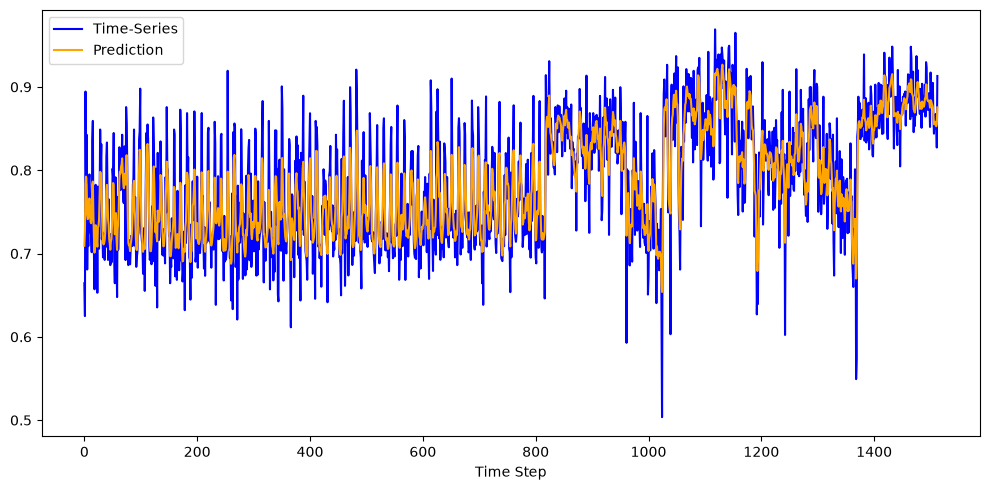

--------------
AWS Signal 6
--------------
Epoch  25 | D Loss: 5.856274 | G Loss: -0.345888
Epoch  50 | D Loss: 2.752288 | G Loss: -0.746201
Epoch  75 | D Loss: 1.905891 | G Loss: -1.219270
Epoch 100 | D Loss: 0.455690 | G Loss: -0.153004
Epoch 125 | D Loss: 0.584576 | G Loss: -0.467757
Epoch 150 | D Loss: 1.376372 | G Loss: -1.436424
Epoch 175 | D Loss: 1.096616 | G Loss: -1.104997
Epoch 200 | D Loss: 0.186572 | G Loss: -0.320009
Epoch 225 | D Loss: 0.077110 | G Loss: -0.106869
Epoch 250 | D Loss: 0.296318 | G Loss: -0.236799
Epoch 275 | D Loss: 0.252023 | G Loss: -0.191954
Epoch 300 | D Loss: 0.030448 | G Loss: 0.083893
Epoch 325 | D Loss: 0.151616 | G Loss: 0.067116
Epoch 350 | D Loss: 0.118118 | G Loss: 0.142656
Epoch 375 | D Loss: 0.046021 | G Loss: 0.244079
Epoch 400 | D Loss: 0.054233 | G Loss: 0.197408
Epoch 425 | D Loss: 0.055987 | G Loss: 0.130835
Epoch 450 | D Loss: 0.057577 | G Loss: 0.119300
Epoch 475 | D Loss: 0.066400 | G Loss: 0.113662
Epoch 500 | D Loss: 0.100559 | G L

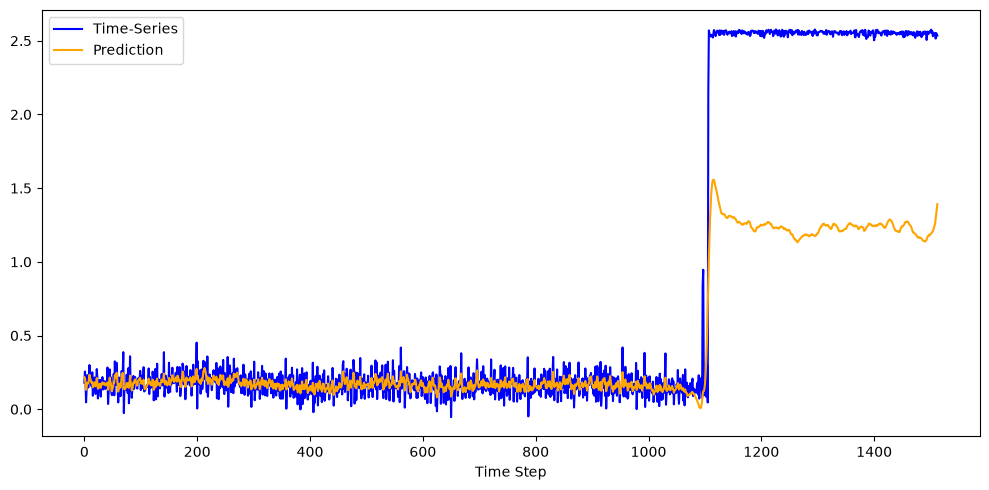

--------------
AWS Signal 7
--------------
Epoch  25 | D Loss: 5.092366 | G Loss: -0.086119
Epoch  50 | D Loss: 2.006108 | G Loss: -0.144102
Epoch  75 | D Loss: 0.931749 | G Loss: -0.593955
Epoch 100 | D Loss: 0.652908 | G Loss: -0.682880
Epoch 125 | D Loss: -0.385933 | G Loss: 0.782167
Epoch 150 | D Loss: 0.274597 | G Loss: 0.095602
Epoch 175 | D Loss: 0.428783 | G Loss: -0.248077
Epoch 200 | D Loss: 0.037678 | G Loss: -0.056838
Epoch 225 | D Loss: 0.015036 | G Loss: -0.036251
Epoch 250 | D Loss: 0.032159 | G Loss: -0.009734
Epoch 275 | D Loss: -0.062313 | G Loss: -0.006787
Epoch 300 | D Loss: -0.107513 | G Loss: 0.043113
Epoch 325 | D Loss: 0.113566 | G Loss: -0.204415
Epoch 350 | D Loss: 0.128308 | G Loss: -0.258816
Epoch 375 | D Loss: 0.159851 | G Loss: -0.309289
Epoch 400 | D Loss: 0.185643 | G Loss: -0.356634
Epoch 425 | D Loss: 0.203552 | G Loss: -0.365690
Epoch 450 | D Loss: 0.315713 | G Loss: -0.456095
Epoch 475 | D Loss: 0.353740 | G Loss: -0.445022
Epoch 500 | D Loss: 0.3466

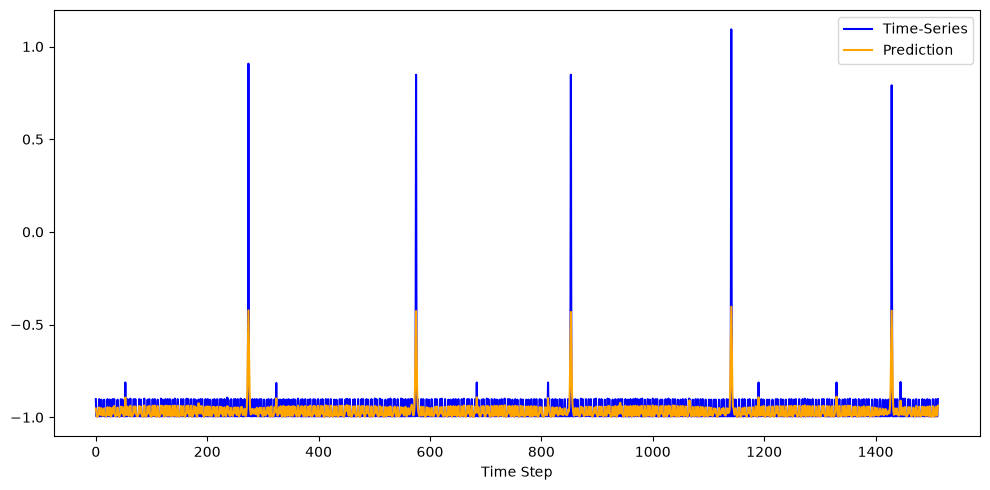

--------------
AWS Signal 8
--------------
Epoch  25 | D Loss: 3.719362 | G Loss: -0.238744
Epoch  50 | D Loss: 2.642802 | G Loss: -0.317579
Epoch  75 | D Loss: 1.524709 | G Loss: 0.000717
Epoch 100 | D Loss: -0.376929 | G Loss: 0.358463
Epoch 125 | D Loss: -1.750262 | G Loss: 0.550863
Epoch 150 | D Loss: 3.196269 | G Loss: -3.324862
Epoch 175 | D Loss: 1.316685 | G Loss: -0.403634
Epoch 200 | D Loss: 0.761408 | G Loss: 0.420670
Epoch 225 | D Loss: 1.340342 | G Loss: -0.848792
Epoch 250 | D Loss: 1.160984 | G Loss: -1.154199
Epoch 275 | D Loss: 0.534360 | G Loss: -0.541177
Epoch 300 | D Loss: 0.111519 | G Loss: -0.019221
Epoch 325 | D Loss: 0.067456 | G Loss: -0.023981
Epoch 350 | D Loss: 0.175892 | G Loss: -0.220018
Epoch 375 | D Loss: 0.210776 | G Loss: -0.185204
Epoch 400 | D Loss: 0.219737 | G Loss: -0.275578
Epoch 425 | D Loss: 0.272893 | G Loss: -0.389703
Epoch 450 | D Loss: 0.292825 | G Loss: -0.317611
Epoch 475 | D Loss: 0.237676 | G Loss: -0.303818
Epoch 500 | D Loss: 0.186513

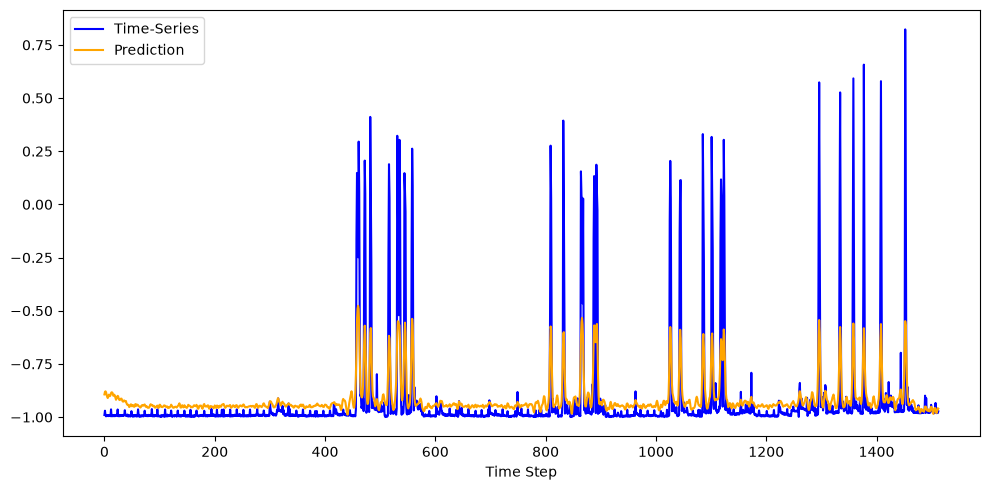

--------------
AWS Signal 9
--------------
Epoch  25 | D Loss: 6.950090 | G Loss: -0.342559
Epoch  50 | D Loss: 6.647224 | G Loss: -2.570362
Epoch  75 | D Loss: 2.048292 | G Loss: -0.017425
Epoch 100 | D Loss: 2.697198 | G Loss: -1.200970
Epoch 125 | D Loss: 2.690972 | G Loss: -1.697480
Epoch 150 | D Loss: 0.761520 | G Loss: -0.463614
Epoch 175 | D Loss: 0.603426 | G Loss: -0.413356
Epoch 200 | D Loss: 0.407517 | G Loss: -0.240529
Epoch 225 | D Loss: 0.288903 | G Loss: -0.148002
Epoch 250 | D Loss: 0.040945 | G Loss: -0.027278
Epoch 275 | D Loss: 0.044583 | G Loss: 0.061575
Epoch 300 | D Loss: 0.040281 | G Loss: 0.118105
Epoch 325 | D Loss: 0.067575 | G Loss: 0.063023
Epoch 350 | D Loss: 0.073484 | G Loss: 0.056407
Epoch 375 | D Loss: 0.077178 | G Loss: 0.080935
Epoch 400 | D Loss: 0.063023 | G Loss: 0.119383
Epoch 425 | D Loss: 0.057105 | G Loss: 0.241008
Epoch 450 | D Loss: 0.053890 | G Loss: 0.385248
Epoch 475 | D Loss: 0.044559 | G Loss: 0.428191
Epoch 500 | D Loss: 0.034782 | G Lo

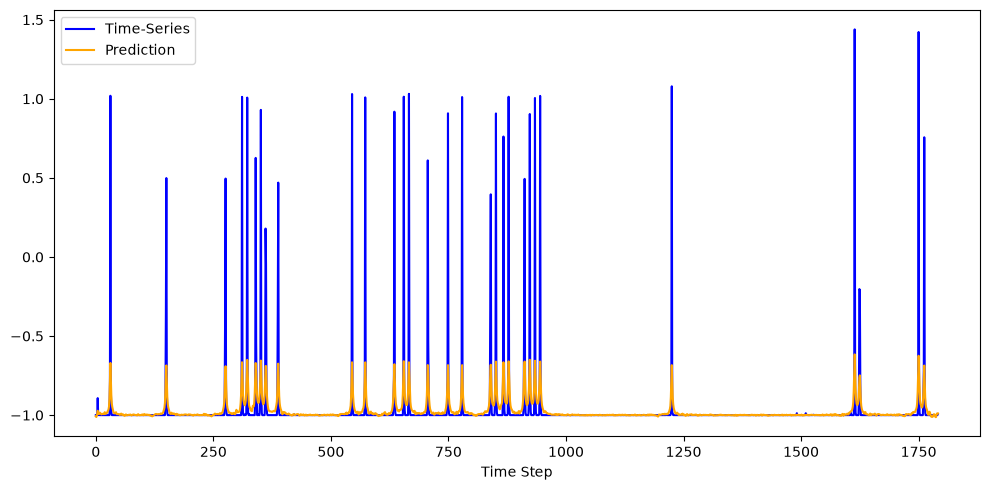

--------------
AWS Signal 10
--------------
Epoch  25 | D Loss: 4.648801 | G Loss: 0.116328
Epoch  50 | D Loss: 1.788355 | G Loss: 0.087942
Epoch  75 | D Loss: 0.417901 | G Loss: -0.034335
Epoch 100 | D Loss: 0.102909 | G Loss: -0.019958
Epoch 125 | D Loss: -0.191865 | G Loss: 0.124675
Epoch 150 | D Loss: 0.082856 | G Loss: -0.025410
Epoch 175 | D Loss: -1.489171 | G Loss: 1.994933
Epoch 200 | D Loss: -0.003998 | G Loss: 0.854830
Epoch 225 | D Loss: -0.267043 | G Loss: 0.211956
Epoch 250 | D Loss: 1.343274 | G Loss: -1.753525
Epoch 275 | D Loss: -0.084560 | G Loss: 0.219778
Epoch 300 | D Loss: 0.212496 | G Loss: -0.013483
Epoch 325 | D Loss: 0.021422 | G Loss: 0.022655
Epoch 350 | D Loss: 0.058841 | G Loss: 0.020999
Epoch 375 | D Loss: 0.037850 | G Loss: 0.017523
Epoch 400 | D Loss: 0.051755 | G Loss: 0.062489
Epoch 425 | D Loss: 0.049725 | G Loss: 0.040656
Epoch 450 | D Loss: 0.031672 | G Loss: 0.069037
Epoch 475 | D Loss: 0.011516 | G Loss: 0.116118
Epoch 500 | D Loss: -0.017895 | G 

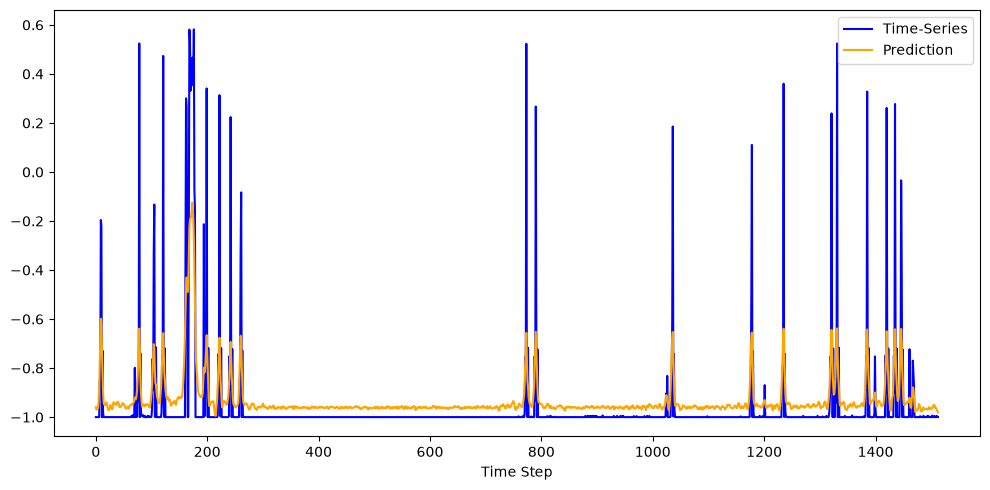

--------------
AWS Signal 11
--------------
Epoch  25 | D Loss: 4.859956 | G Loss: -0.761437
Epoch  50 | D Loss: 2.432680 | G Loss: 0.049789
Epoch  75 | D Loss: 1.560767 | G Loss: -0.397172
Epoch 100 | D Loss: 0.214104 | G Loss: 0.059718
Epoch 125 | D Loss: 1.200199 | G Loss: -1.216817
Epoch 150 | D Loss: 0.753058 | G Loss: -0.626237
Epoch 175 | D Loss: 0.358368 | G Loss: -0.358538
Epoch 200 | D Loss: 0.254854 | G Loss: -0.329198
Epoch 225 | D Loss: 0.752161 | G Loss: -0.487856
Epoch 250 | D Loss: 0.199575 | G Loss: -0.145340
Epoch 275 | D Loss: 0.095771 | G Loss: -0.073698
Epoch 300 | D Loss: -0.128273 | G Loss: 0.099183
Epoch 325 | D Loss: 0.010789 | G Loss: 0.150048
Epoch 350 | D Loss: -0.032217 | G Loss: 0.187165
Epoch 375 | D Loss: -0.168960 | G Loss: 0.399574
Epoch 400 | D Loss: -0.052042 | G Loss: 0.152660
Epoch 425 | D Loss: 0.029415 | G Loss: -0.034969
Epoch 450 | D Loss: 0.055280 | G Loss: -0.143963
Epoch 475 | D Loss: 0.057093 | G Loss: -0.087431
Epoch 500 | D Loss: 0.058246

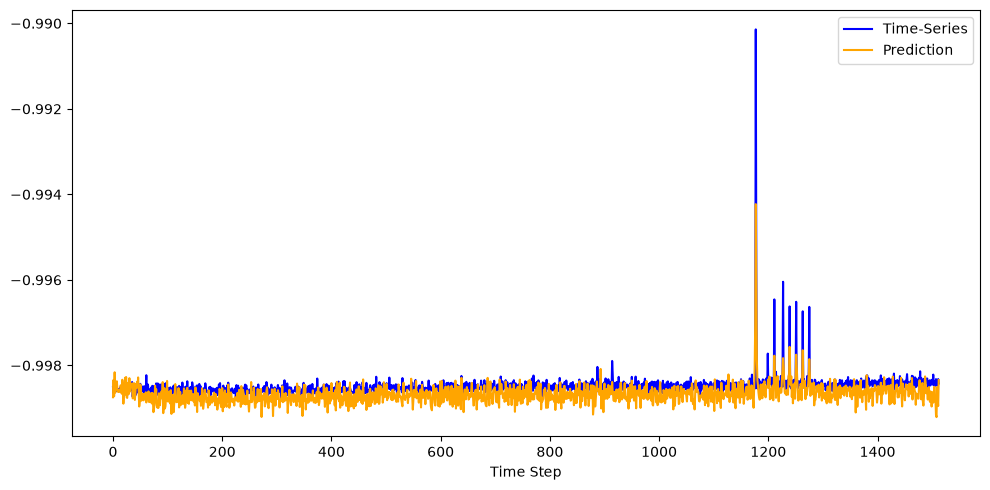

--------------
AWS Signal 12
--------------
Epoch  25 | D Loss: 2.539816 | G Loss: 0.419941
Epoch  50 | D Loss: 0.808802 | G Loss: 0.006436
Epoch  75 | D Loss: 2.231560 | G Loss: -1.817001
Epoch 100 | D Loss: 1.446641 | G Loss: -1.204916
Epoch 125 | D Loss: 0.348930 | G Loss: -0.164811
Epoch 150 | D Loss: -0.482674 | G Loss: 0.465843
Epoch 175 | D Loss: 0.954540 | G Loss: -0.993847
Epoch 200 | D Loss: 0.442608 | G Loss: -0.411026
Epoch 225 | D Loss: 0.149410 | G Loss: -0.059890
Epoch 250 | D Loss: 0.250325 | G Loss: -0.140744
Epoch 275 | D Loss: 0.410288 | G Loss: -0.338442
Epoch 300 | D Loss: 0.470343 | G Loss: -0.405881
Epoch 325 | D Loss: 0.442552 | G Loss: -0.356869
Epoch 350 | D Loss: 0.466062 | G Loss: -0.334569
Epoch 375 | D Loss: 0.496915 | G Loss: -0.363859
Epoch 400 | D Loss: 0.462506 | G Loss: -0.319783
Epoch 425 | D Loss: 0.445328 | G Loss: -0.261286
Epoch 450 | D Loss: 0.409934 | G Loss: -0.153734
Epoch 475 | D Loss: 0.368329 | G Loss: -0.017286
Epoch 500 | D Loss: 0.29109

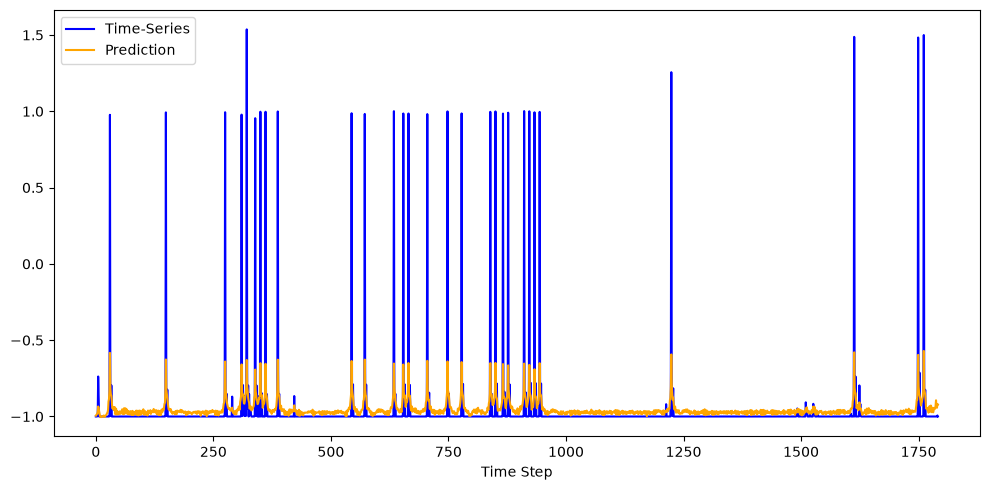

--------------
AWS Signal 13
--------------
Epoch  25 | D Loss: 3.509487 | G Loss: -0.012246
Epoch  50 | D Loss: 0.650105 | G Loss: -0.149264
Epoch  75 | D Loss: 0.202408 | G Loss: -0.233611
Epoch 100 | D Loss: -0.854365 | G Loss: 0.959470
Epoch 125 | D Loss: 0.076072 | G Loss: -0.028805
Epoch 150 | D Loss: 0.005904 | G Loss: -0.071400
Epoch 175 | D Loss: 0.007368 | G Loss: -0.075203
Epoch 200 | D Loss: 0.003962 | G Loss: -0.070654
Epoch 225 | D Loss: 0.023023 | G Loss: -0.116384
Epoch 250 | D Loss: 0.014343 | G Loss: -0.097857
Epoch 275 | D Loss: 0.006516 | G Loss: -0.066518
Epoch 300 | D Loss: 0.012306 | G Loss: -0.077296
Epoch 325 | D Loss: -0.024132 | G Loss: -0.038813
Epoch 350 | D Loss: -0.026469 | G Loss: -0.021716
Epoch 375 | D Loss: -0.050857 | G Loss: -0.023130
Epoch 400 | D Loss: -0.076151 | G Loss: -0.002340
Epoch 425 | D Loss: -0.116534 | G Loss: -0.027117
Epoch 450 | D Loss: -0.169714 | G Loss: -0.010701
Epoch 475 | D Loss: -0.233386 | G Loss: -0.017020
Epoch 500 | D Loss

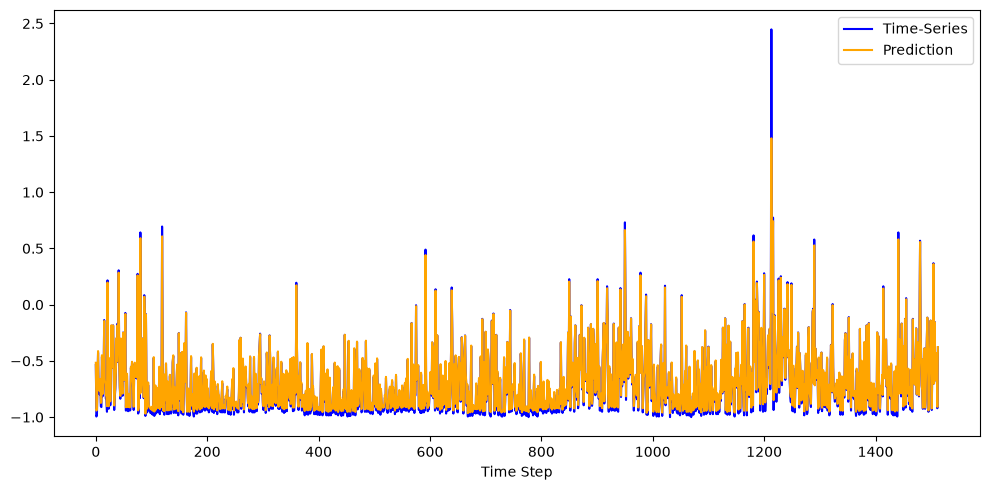

--------------
AWS Signal 14
--------------
Epoch  25 | D Loss: 3.250104 | G Loss: 0.149363
Epoch  50 | D Loss: 0.677606 | G Loss: 0.118186
Epoch  75 | D Loss: -0.368343 | G Loss: 0.501003
Epoch 100 | D Loss: 2.032902 | G Loss: -2.138595
Epoch 125 | D Loss: 2.559282 | G Loss: -2.618895
Epoch 150 | D Loss: 1.026473 | G Loss: -0.818139
Epoch 175 | D Loss: 0.034628 | G Loss: 0.281706
Epoch 200 | D Loss: 0.117420 | G Loss: 0.096291
Epoch 225 | D Loss: 0.221316 | G Loss: -0.044056
Epoch 250 | D Loss: 0.249290 | G Loss: -0.054109
Epoch 275 | D Loss: 0.096142 | G Loss: 0.109960
Epoch 300 | D Loss: 0.251464 | G Loss: 0.009095
Epoch 325 | D Loss: 0.166729 | G Loss: 0.216019
Epoch 350 | D Loss: 0.066599 | G Loss: 0.384899
Epoch 375 | D Loss: 0.030918 | G Loss: 0.488564
Epoch 400 | D Loss: 0.018980 | G Loss: 0.505152
Epoch 425 | D Loss: 0.023927 | G Loss: 0.446909
Epoch 450 | D Loss: 0.023254 | G Loss: 0.408131
Epoch 475 | D Loss: 0.022339 | G Loss: 0.391862
Epoch 500 | D Loss: 0.019346 | G Loss:

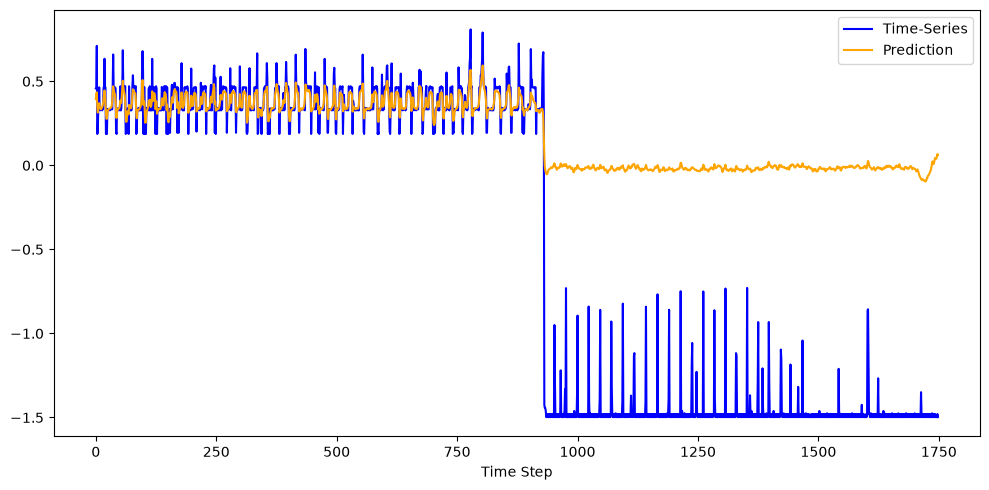

--------------
AWS Signal 15
--------------
Epoch  25 | D Loss: 6.959210 | G Loss: -0.011703
Epoch  50 | D Loss: 6.014808 | G Loss: -0.010545
Epoch  75 | D Loss: 5.001783 | G Loss: -0.009355
Epoch 100 | D Loss: 3.999514 | G Loss: -0.008462
Epoch 125 | D Loss: 3.088867 | G Loss: -0.061106
Epoch 150 | D Loss: 2.307261 | G Loss: -0.121042
Epoch 175 | D Loss: 1.596080 | G Loss: -0.127498
Epoch 200 | D Loss: 1.162807 | G Loss: -0.120224
Epoch 225 | D Loss: 0.864097 | G Loss: -0.124166
Epoch 250 | D Loss: 0.606124 | G Loss: -0.131402
Epoch 275 | D Loss: 0.524970 | G Loss: -0.342938
Epoch 300 | D Loss: 0.584837 | G Loss: -0.532945
Epoch 325 | D Loss: 0.534343 | G Loss: -0.557013
Epoch 350 | D Loss: 0.439150 | G Loss: -0.479259
Epoch 375 | D Loss: 0.206540 | G Loss: -0.227276
Epoch 400 | D Loss: 0.004047 | G Loss: 0.037265
Epoch 425 | D Loss: -0.412986 | G Loss: 0.563035
Epoch 450 | D Loss: 0.230368 | G Loss: 0.081687
Epoch 475 | D Loss: -0.131930 | G Loss: 0.544421
Epoch 500 | D Loss: -0.3225

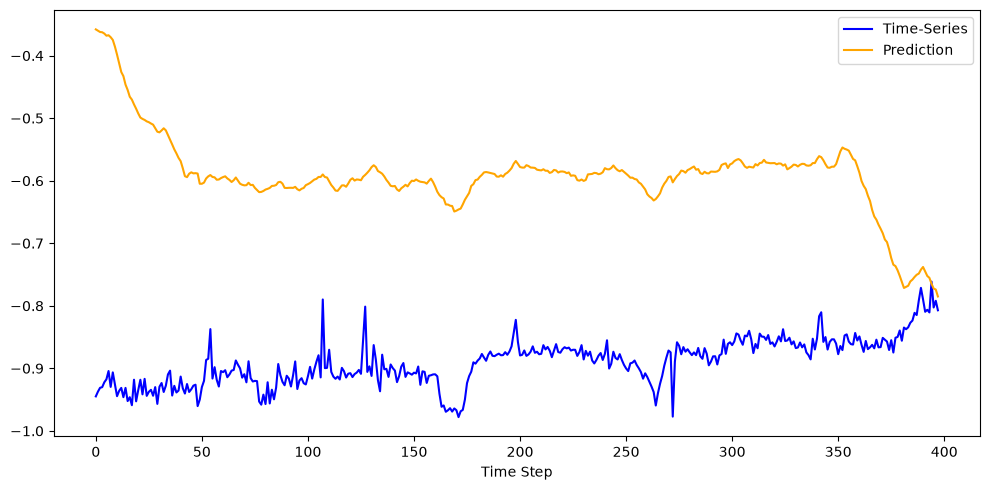

--------------
AWS Signal 16
--------------
Epoch  25 | D Loss: 5.390482 | G Loss: -0.225864
Epoch  50 | D Loss: 1.960365 | G Loss: 0.084814
Epoch  75 | D Loss: 0.302271 | G Loss: -0.081968
Epoch 100 | D Loss: 5.235618 | G Loss: -5.057678
Epoch 125 | D Loss: 3.610577 | G Loss: -3.026526
Epoch 150 | D Loss: 1.772171 | G Loss: -1.435615
Epoch 175 | D Loss: 1.133117 | G Loss: -0.988438
Epoch 200 | D Loss: 0.387672 | G Loss: -0.321612
Epoch 225 | D Loss: 0.774784 | G Loss: -0.732019
Epoch 250 | D Loss: 1.461935 | G Loss: -1.234295
Epoch 275 | D Loss: 0.877408 | G Loss: -0.692844
Epoch 300 | D Loss: 0.526506 | G Loss: -0.344474
Epoch 325 | D Loss: 0.450623 | G Loss: -0.231609
Epoch 350 | D Loss: 0.272680 | G Loss: -0.021452
Epoch 375 | D Loss: -0.325353 | G Loss: 0.814072
Epoch 400 | D Loss: -0.196845 | G Loss: 0.902439
Epoch 425 | D Loss: 0.184344 | G Loss: 0.642380
Epoch 450 | D Loss: 0.134966 | G Loss: 0.570116
Epoch 475 | D Loss: 0.073540 | G Loss: 0.478829
Epoch 500 | D Loss: 0.088299 

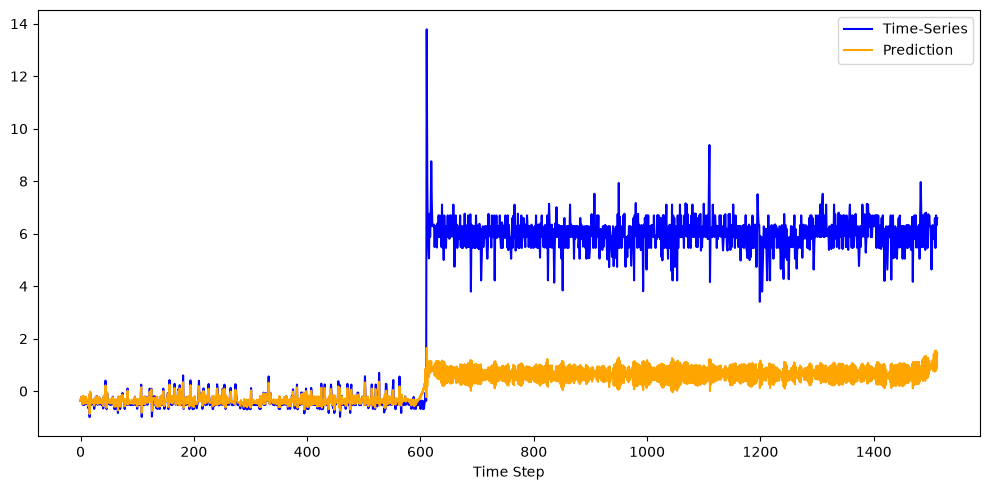

--------------
AWS Signal 17
--------------
Epoch  25 | D Loss: 2.583948 | G Loss: 0.002879
Epoch  50 | D Loss: 0.658970 | G Loss: 0.229077
Epoch  75 | D Loss: 0.444622 | G Loss: -0.282426
Epoch 100 | D Loss: 0.300846 | G Loss: -0.166297
Epoch 125 | D Loss: 0.030696 | G Loss: 0.147046
Epoch 150 | D Loss: 0.464041 | G Loss: -0.218895
Epoch 175 | D Loss: 0.458557 | G Loss: -0.281750
Epoch 200 | D Loss: 0.276514 | G Loss: -0.241947
Epoch 225 | D Loss: 0.352326 | G Loss: -0.254955
Epoch 250 | D Loss: 0.381706 | G Loss: -0.280793
Epoch 275 | D Loss: 0.280852 | G Loss: -0.200072
Epoch 300 | D Loss: 0.167846 | G Loss: -0.058908
Epoch 325 | D Loss: 0.118348 | G Loss: -0.014960
Epoch 350 | D Loss: 0.104298 | G Loss: 0.002811
Epoch 375 | D Loss: 0.100296 | G Loss: -0.005086
Epoch 400 | D Loss: 0.111611 | G Loss: -0.047522
Epoch 425 | D Loss: 0.087716 | G Loss: 0.074411
Epoch 450 | D Loss: 0.041055 | G Loss: -0.106444
Epoch 475 | D Loss: 0.060571 | G Loss: -0.063226
Epoch 500 | D Loss: 0.059777 |

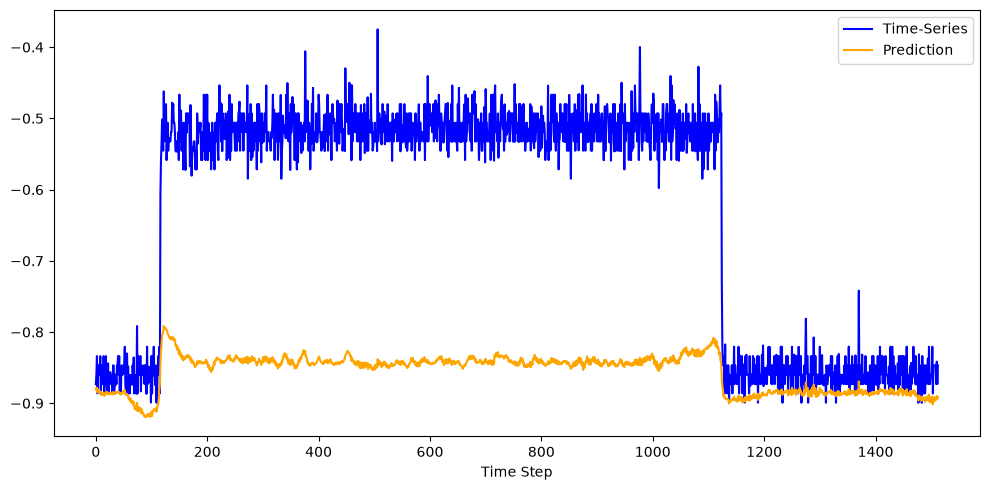

------------------
AWS Metrics
------------------
[point] Precision: 0.819 | Recall: 1.417 | F1: 0.948
[area] Precision: 0.534 | Recall: 1.333 | F1: 0.694


In [39]:
total_metrics = {name: np.zeros(3) for (name, _) in NAB_HYPERPARAMS["rec_error_funcs"]}

for i, aws_signal in enumerate(aws_signals):
    X = aws_signal['value'].to_numpy()
    # expand from shape (T, ) to (T, 1)  
    X = np.expand_dims(X, axis=1)
    y = aws_signal['is_anomaly'].to_numpy()
    
    print("--------------")
    print(f"AWS Signal {i + 1}")
    print("--------------")

    metrics = run_pipeline(X, y, **NAB_HYPERPARAMS)

    for key in total_metrics:
        total_metrics[key] += np.array(metrics[key])

print("------------------")
print("AWS Metrics")
print("------------------")

for key in total_metrics:
    total_metrics[key] = total_metrics[key] / len(art_signals)
    print(f"[{key}] Precision: {total_metrics[key][0]:.3f} | Recall: {total_metrics[key][1]:.3f} | F1: {total_metrics[key][2]:.3f}")

### **Real Traffic**

In [44]:
traffic_signals = nab_download_subdataset(folder=TRAFFIC_FOLDER, file_names=TRAFFIC_FILE_NAMES, nab_labels=nab_labels)

Downloaded 5 .csv files.

Finished downloading realTraffic/!
---------------------
Total Signals: 7
Total Points: 15664
Total Anomaly Points: 1560
Anomaly Rate: 9.96%


--------------
Traffic Signal 1
--------------
Epoch  25 | D Loss: 5.461773 | G Loss: 0.022443
Epoch  50 | D Loss: 2.854771 | G Loss: 0.135559
Epoch  75 | D Loss: 1.826451 | G Loss: 0.117120
Epoch 100 | D Loss: 0.648120 | G Loss: -0.086080
Epoch 125 | D Loss: 0.523791 | G Loss: -0.001675
Epoch 150 | D Loss: 0.466722 | G Loss: -0.590086
Epoch 175 | D Loss: 0.537183 | G Loss: -0.542367
Epoch 200 | D Loss: 1.026943 | G Loss: -0.881823
Epoch 225 | D Loss: 0.627606 | G Loss: -0.511811
Epoch 250 | D Loss: -0.045985 | G Loss: 0.164647
Epoch 275 | D Loss: 0.162946 | G Loss: -0.084131
Epoch 300 | D Loss: 0.390760 | G Loss: -0.264789
Epoch 325 | D Loss: 0.204327 | G Loss: -0.106704
Epoch 350 | D Loss: 0.036177 | G Loss: 0.068815
Epoch 375 | D Loss: -0.013321 | G Loss: 0.093588
Epoch 400 | D Loss: -0.593312 | G Loss: 0.622427
Epoch 425 | D Loss: 0.498196 | G Loss: -0.288390
Epoch 450 | D Loss: -0.054652 | G Loss: 0.121450
Epoch 475 | D Loss: 0.247919 | G Loss: -0.229538
Epoch 500 | D Loss: 0.0571

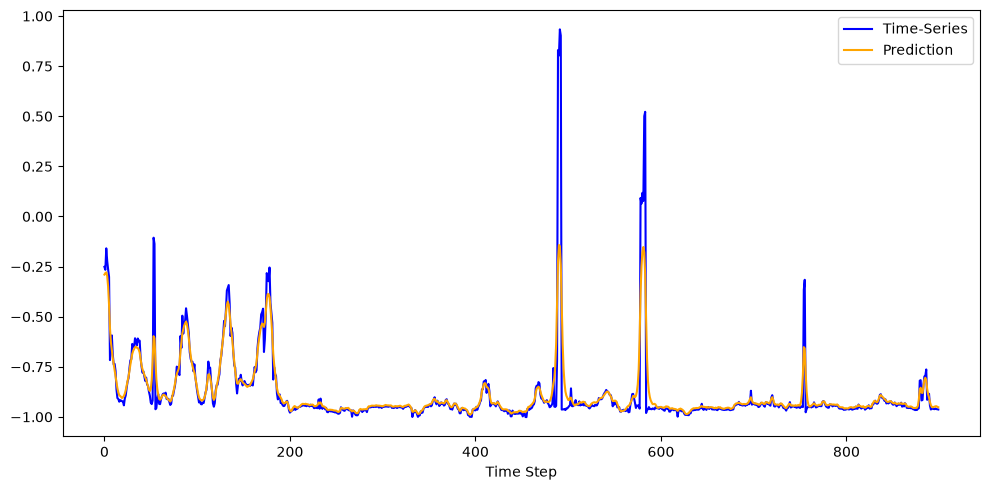

--------------
Traffic Signal 2
--------------
Epoch  25 | D Loss: 6.680001 | G Loss: -0.068133
Epoch  50 | D Loss: 4.287914 | G Loss: -0.036789
Epoch  75 | D Loss: 2.180069 | G Loss: 0.049336
Epoch 100 | D Loss: 1.054592 | G Loss: 0.050024
Epoch 125 | D Loss: 0.336240 | G Loss: 0.049419
Epoch 150 | D Loss: 0.450839 | G Loss: -0.245743
Epoch 175 | D Loss: 0.474081 | G Loss: -0.319946
Epoch 200 | D Loss: 0.119518 | G Loss: -0.042644
Epoch 225 | D Loss: 0.080712 | G Loss: -0.007253
Epoch 250 | D Loss: -0.021580 | G Loss: 0.104179
Epoch 275 | D Loss: -0.162838 | G Loss: 0.273903
Epoch 300 | D Loss: 0.698875 | G Loss: -0.541943
Epoch 325 | D Loss: 0.608048 | G Loss: -0.515844
Epoch 350 | D Loss: 0.345422 | G Loss: -0.248402
Epoch 375 | D Loss: 0.027357 | G Loss: 0.077329
Epoch 400 | D Loss: -0.256804 | G Loss: 0.361889
Epoch 425 | D Loss: 0.636752 | G Loss: -0.588433
Epoch 450 | D Loss: -0.044594 | G Loss: 0.202653
Epoch 475 | D Loss: -0.681076 | G Loss: 1.169921
Epoch 500 | D Loss: 0.9247

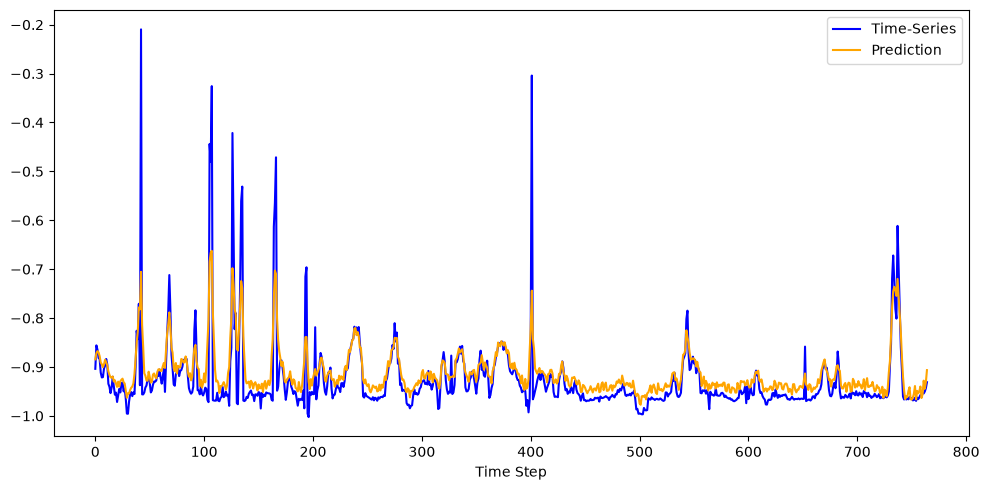

--------------
Traffic Signal 3
--------------
Epoch  25 | D Loss: 5.629513 | G Loss: 0.010677
Epoch  50 | D Loss: 3.655885 | G Loss: -0.008424
Epoch  75 | D Loss: 1.806271 | G Loss: -0.429692
Epoch 100 | D Loss: 1.216777 | G Loss: -0.573801
Epoch 125 | D Loss: 0.295825 | G Loss: -0.061882
Epoch 150 | D Loss: 0.259252 | G Loss: -0.103744
Epoch 175 | D Loss: 0.216355 | G Loss: -0.087446
Epoch 200 | D Loss: 0.149572 | G Loss: -0.059561
Epoch 225 | D Loss: 0.094976 | G Loss: -0.005009
Epoch 250 | D Loss: 0.097778 | G Loss: -0.009447
Epoch 275 | D Loss: 0.140573 | G Loss: -0.101103
Epoch 300 | D Loss: 0.162656 | G Loss: -0.134171
Epoch 325 | D Loss: 0.162408 | G Loss: -0.152381
Epoch 350 | D Loss: 0.149193 | G Loss: -0.125209
Epoch 375 | D Loss: 0.131516 | G Loss: -0.090394
Epoch 400 | D Loss: 0.111632 | G Loss: -0.054215
Epoch 425 | D Loss: 0.106037 | G Loss: -0.039181
Epoch 450 | D Loss: 0.102088 | G Loss: -0.037796
Epoch 475 | D Loss: 0.105930 | G Loss: -0.034046
Epoch 500 | D Loss: 0.1

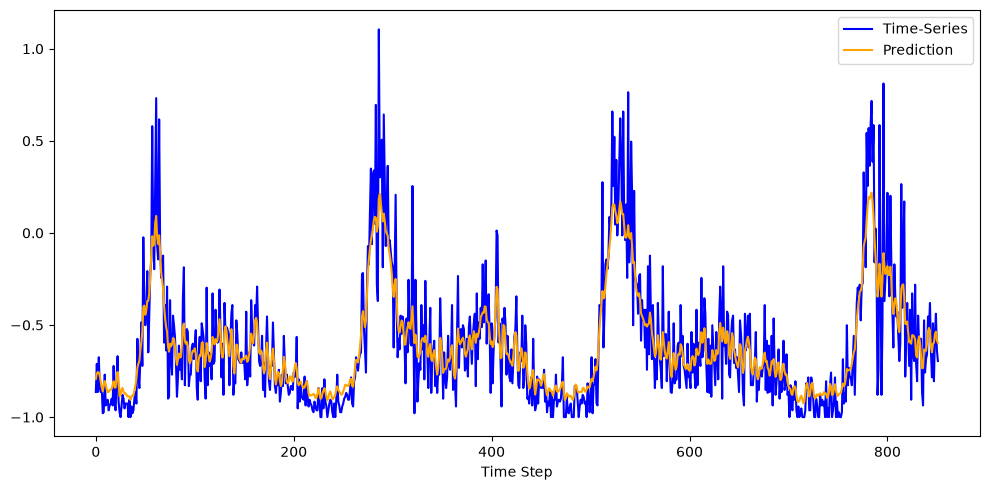

--------------
Traffic Signal 4
--------------
Epoch  25 | D Loss: 5.318697 | G Loss: -0.116232
Epoch  50 | D Loss: 4.276410 | G Loss: -0.226590
Epoch  75 | D Loss: 2.651664 | G Loss: -0.169371
Epoch 100 | D Loss: 2.507285 | G Loss: -0.689149
Epoch 125 | D Loss: 1.708215 | G Loss: -0.659140
Epoch 150 | D Loss: 1.323072 | G Loss: -0.690437
Epoch 175 | D Loss: 0.700559 | G Loss: -0.453287
Epoch 200 | D Loss: -0.002340 | G Loss: -0.055473
Epoch 225 | D Loss: 0.464163 | G Loss: -0.695597
Epoch 250 | D Loss: 0.642176 | G Loss: -0.806150
Epoch 275 | D Loss: 0.621049 | G Loss: -0.743996
Epoch 300 | D Loss: 0.553903 | G Loss: -0.656618
Epoch 325 | D Loss: 0.482613 | G Loss: -0.568480
Epoch 350 | D Loss: 0.412117 | G Loss: -0.480158
Epoch 375 | D Loss: 0.311400 | G Loss: -0.341563
Epoch 400 | D Loss: 0.112389 | G Loss: -0.043779
Epoch 425 | D Loss: -0.095412 | G Loss: 0.233126
Epoch 450 | D Loss: 0.152056 | G Loss: -0.170008
Epoch 475 | D Loss: 0.161949 | G Loss: -0.161958
Epoch 500 | D Loss: 0

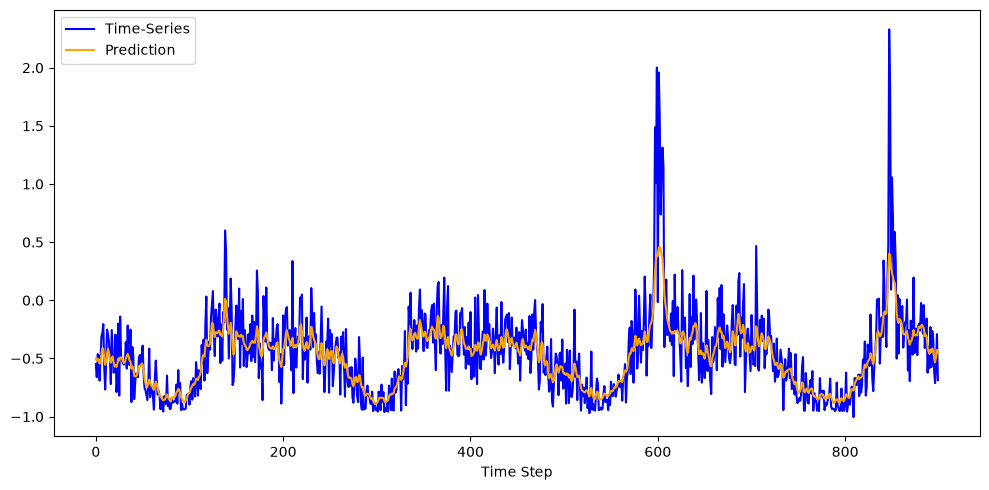

--------------
Traffic Signal 5
--------------
Epoch  25 | D Loss: 5.801772 | G Loss: -0.103267
Epoch  50 | D Loss: 3.716236 | G Loss: -0.057557
Epoch  75 | D Loss: 2.191728 | G Loss: -0.321021
Epoch 100 | D Loss: 3.711578 | G Loss: -2.412772
Epoch 125 | D Loss: 3.840113 | G Loss: -3.103320
Epoch 150 | D Loss: 3.396826 | G Loss: -2.944834
Epoch 175 | D Loss: 2.462516 | G Loss: -2.152029
Epoch 200 | D Loss: 1.700329 | G Loss: -1.509852
Epoch 225 | D Loss: 1.171398 | G Loss: -1.076056
Epoch 250 | D Loss: 0.850614 | G Loss: -0.802259
Epoch 275 | D Loss: 0.717900 | G Loss: -0.700784
Epoch 300 | D Loss: 0.711647 | G Loss: -0.698811
Epoch 325 | D Loss: 0.595939 | G Loss: -0.619261
Epoch 350 | D Loss: 0.461811 | G Loss: -0.502680
Epoch 375 | D Loss: 0.055463 | G Loss: -0.109852
Epoch 400 | D Loss: -0.442839 | G Loss: 0.506337
Epoch 425 | D Loss: -0.556057 | G Loss: 0.691179
Epoch 450 | D Loss: -0.088949 | G Loss: 0.273097
Epoch 475 | D Loss: 0.280149 | G Loss: -0.112013
Epoch 500 | D Loss: 0.

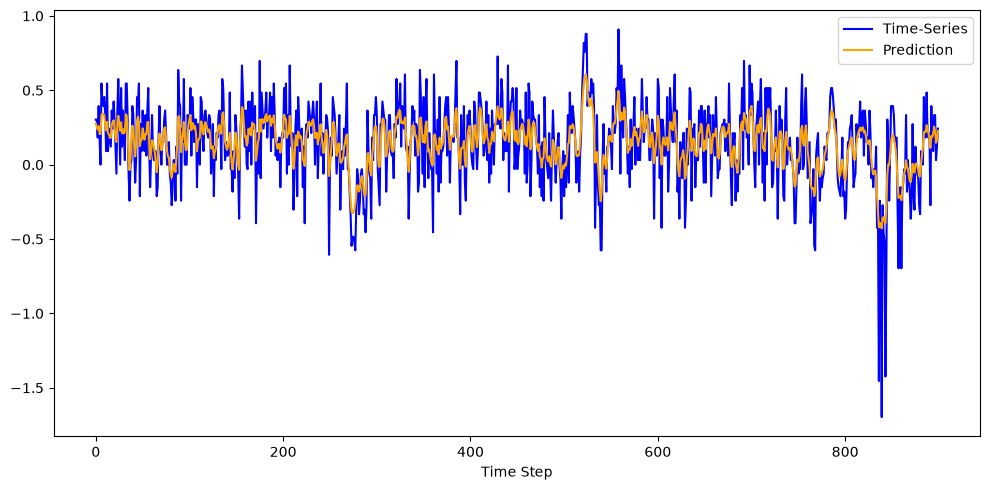

--------------
Traffic Signal 6
--------------
Epoch  25 | D Loss: 7.353028 | G Loss: -0.001876
Epoch  50 | D Loss: 6.462144 | G Loss: 0.013062
Epoch  75 | D Loss: 5.512939 | G Loss: 0.018951
Epoch 100 | D Loss: 4.699946 | G Loss: 0.007396
Epoch 125 | D Loss: 3.738558 | G Loss: -0.156217
Epoch 150 | D Loss: 3.824300 | G Loss: -0.632258
Epoch 175 | D Loss: 2.753533 | G Loss: -0.183515
Epoch 200 | D Loss: 1.991653 | G Loss: -0.015662
Epoch 225 | D Loss: 1.269882 | G Loss: 0.218949
Epoch 250 | D Loss: 1.320579 | G Loss: -0.140447
Epoch 275 | D Loss: 0.986775 | G Loss: -0.216145
Epoch 300 | D Loss: 0.741932 | G Loss: -0.283939
Epoch 325 | D Loss: 0.463984 | G Loss: -0.295685
Epoch 350 | D Loss: 0.206448 | G Loss: -0.150562
Epoch 375 | D Loss: -0.150559 | G Loss: 0.121383
Epoch 400 | D Loss: -0.278377 | G Loss: 0.224040
Epoch 425 | D Loss: -0.251014 | G Loss: 0.136633
Epoch 450 | D Loss: 1.947769 | G Loss: -1.945437
Epoch 475 | D Loss: 0.950780 | G Loss: -0.881444
Epoch 500 | D Loss: 0.0045

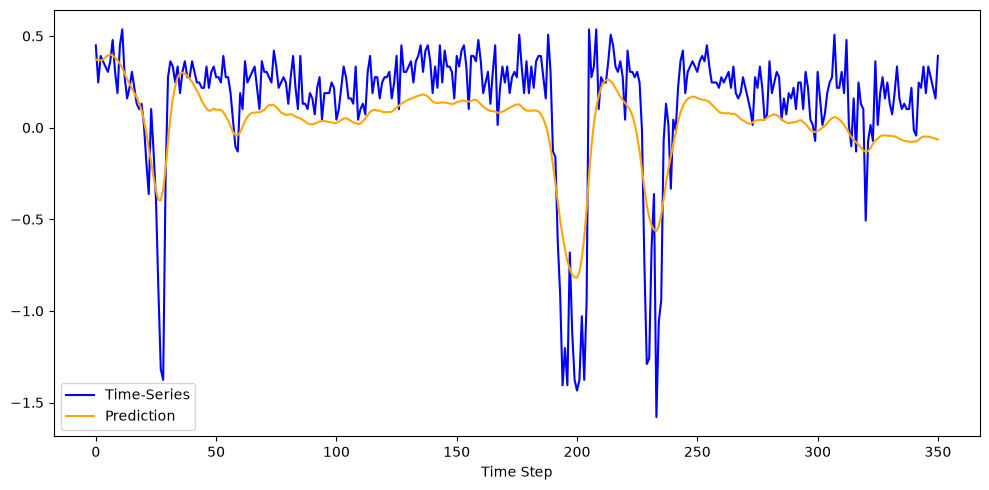

--------------
Traffic Signal 7
--------------
Epoch  25 | D Loss: 5.038311 | G Loss: -0.077596
Epoch  50 | D Loss: 3.045318 | G Loss: 0.022105
Epoch  75 | D Loss: 3.326249 | G Loss: -2.284073
Epoch 100 | D Loss: 7.080090 | G Loss: -5.667744
Epoch 125 | D Loss: 6.312283 | G Loss: -4.495523
Epoch 150 | D Loss: 3.709250 | G Loss: -2.396828
Epoch 175 | D Loss: 0.659295 | G Loss: 0.079732
Epoch 200 | D Loss: -1.282456 | G Loss: 1.818305
Epoch 225 | D Loss: -0.419596 | G Loss: 0.324194
Epoch 250 | D Loss: 1.137704 | G Loss: -1.621247
Epoch 275 | D Loss: 2.341214 | G Loss: -2.518279
Epoch 300 | D Loss: 3.837010 | G Loss: -3.541298
Epoch 325 | D Loss: 2.853104 | G Loss: -2.431782
Epoch 350 | D Loss: 0.663311 | G Loss: -0.508779
Epoch 375 | D Loss: -1.082022 | G Loss: 0.996955
Epoch 400 | D Loss: -1.678344 | G Loss: 1.484688
Epoch 425 | D Loss: -1.016011 | G Loss: 0.999434
Epoch 450 | D Loss: 0.145793 | G Loss: -0.030581
Epoch 475 | D Loss: 1.393423 | G Loss: -1.427025
Epoch 500 | D Loss: 1.94

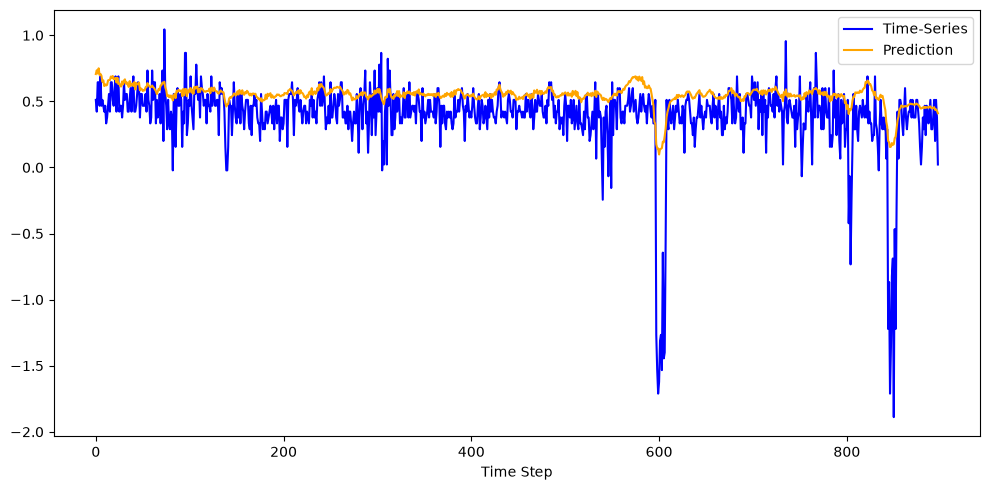

------------------
Real Traffic Metrics
------------------
[point] Precision: 0.071 | Recall: 0.071 | F1: 0.071
[area] Precision: 0.214 | Recall: 0.429 | F1: 0.271


In [45]:
total_metrics = {name: np.zeros(3) for (name, _) in NAB_HYPERPARAMS["rec_error_funcs"]}

for i, traffic_signal in enumerate(traffic_signals):
    X = traffic_signal['value'].to_numpy()
    # expand from shape (T, ) to (T, 1)  
    X = np.expand_dims(X, axis=1)
    y = traffic_signal['is_anomaly'].to_numpy()

    print("--------------")
    print(f"Traffic Signal {i + 1}")
    print("--------------")

    metrics = run_pipeline(X, y, **NAB_HYPERPARAMS)

    for key in total_metrics:
        total_metrics[key] += np.array(metrics[key])

print("------------------")
print("Real Traffic Metrics")
print("------------------")

for key in total_metrics:
    total_metrics[key] = total_metrics[key] / len(traffic_signals)
    print(f"[{key}] Precision: {total_metrics[key][0]:.3f} | Recall: {total_metrics[key][1]:.3f} | F1: {total_metrics[key][2]:.3f}")

### **Twitter**

In [11]:
twitter_signals = nab_download_subdataset(folder=TWEETS_FOLDER, file_names=TWEETS_FILE_NAMES, nab_labels=nab_labels)

Downloaded 5 .csv files.
Downloaded 10 .csv files.

Finished downloading realTweets/!
---------------------
Total Signals: 10
Total Points: 158631
Total Anomaly Points: 15651
Anomaly Rate: 9.87%


--------------
Twitter Signal 1
--------------


/venv/main/lib/python3.12/site-packages/torch/autograd/graph.py:869: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:335.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch  25 | D Loss: 0.249015 | G Loss: -1.708072
Epoch  50 | D Loss: 2.244457 | G Loss: -1.603440
Epoch  75 | D Loss: 1.211105 | G Loss: -1.929862
Epoch 100 | D Loss: 0.444201 | G Loss: -0.336162
Epoch 125 | D Loss: 0.379540 | G Loss: -0.546732
Epoch 150 | D Loss: 0.234106 | G Loss: -0.240407
Epoch 175 | D Loss: 0.170207 | G Loss: -0.217600
Epoch 200 | D Loss: 0.045002 | G Loss: -0.353545
Epoch 225 | D Loss: 0.028353 | G Loss: -0.936533
Epoch 250 | D Loss: 0.007588 | G Loss: -0.713091
Epoch 275 | D Loss: -0.006205 | G Loss: -1.382412
Epoch 300 | D Loss: -0.016337 | G Loss: -2.130697
Epoch 325 | D Loss: -0.019371 | G Loss: -2.434755
Epoch 350 | D Loss: -0.011751 | G Loss: -2.427092
Epoch 375 | D Loss: -0.019073 | G Loss: -2.267911
Epoch 400 | D Loss: -0.019331 | G Loss: -2.048627
Epoch 425 | D Loss: -0.022551 | G Loss: -2.682850
Epoch 450 | D Loss: -0.008360 | G Loss: -2.244682
Epoch 475 | D Loss: -0.000232 | G Loss: -2.642875
Epoch 500 | D Loss: -0.002923 | G Loss: -2.463620
Epoch 525 

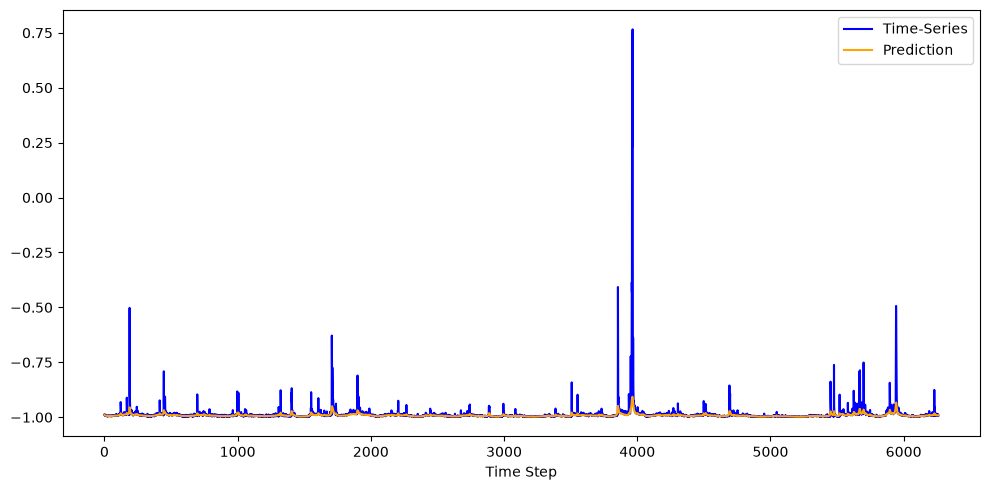

--------------
Twitter Signal 2
--------------
Epoch  25 | D Loss: 0.121938 | G Loss: -0.322209
Epoch  50 | D Loss: 0.216711 | G Loss: -0.357103
Epoch  75 | D Loss: 0.072485 | G Loss: -0.272184
Epoch 100 | D Loss: 0.002199 | G Loss: -0.256751
Epoch 125 | D Loss: 0.418627 | G Loss: -0.437456
Epoch 150 | D Loss: 0.021525 | G Loss: -0.119303
Epoch 175 | D Loss: 0.065044 | G Loss: -0.398771
Epoch 200 | D Loss: 0.235269 | G Loss: -0.617030
Epoch 225 | D Loss: 0.107823 | G Loss: -0.851635
Epoch 250 | D Loss: 0.118736 | G Loss: -0.430443
Epoch 275 | D Loss: 0.103156 | G Loss: 0.267058
Epoch 300 | D Loss: 0.204436 | G Loss: 0.423375
Epoch 325 | D Loss: 0.144785 | G Loss: 0.725469
Epoch 350 | D Loss: 0.189957 | G Loss: -0.365430
Epoch 375 | D Loss: 0.125580 | G Loss: -0.441478
Epoch 400 | D Loss: 0.126886 | G Loss: -0.202539
Epoch 425 | D Loss: 0.166115 | G Loss: -0.212216
Epoch 450 | D Loss: 0.142678 | G Loss: -0.366844
Epoch 475 | D Loss: 0.126297 | G Loss: -0.661982
Epoch 500 | D Loss: 0.116

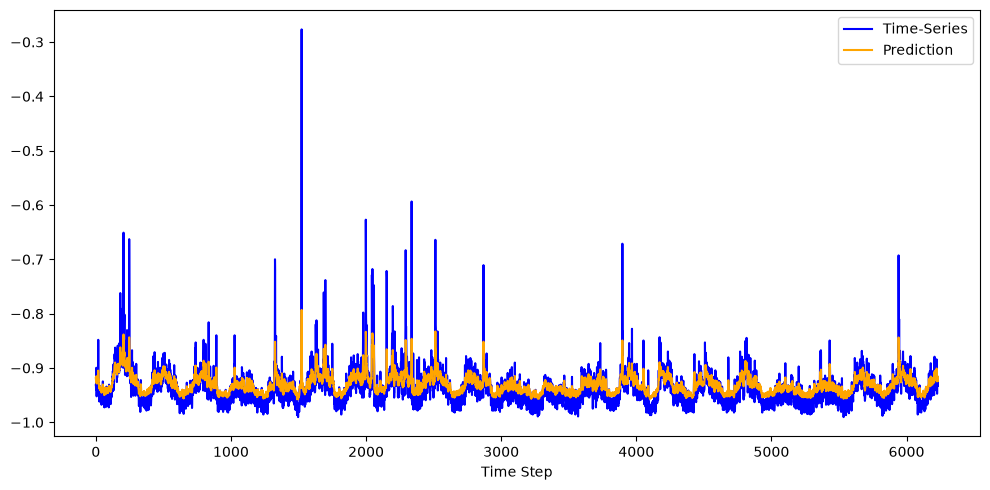

--------------
Twitter Signal 3
--------------
Epoch  25 | D Loss: 0.141929 | G Loss: 0.078216
Epoch  50 | D Loss: 0.396436 | G Loss: -0.015986
Epoch  75 | D Loss: -0.014676 | G Loss: 0.490870
Epoch 100 | D Loss: 0.008747 | G Loss: 0.757606
Epoch 125 | D Loss: 0.064110 | G Loss: 0.991995
Epoch 150 | D Loss: 0.051332 | G Loss: 1.239595
Epoch 175 | D Loss: 0.017493 | G Loss: 1.656518
Epoch 200 | D Loss: 0.028016 | G Loss: 1.658734
Epoch 225 | D Loss: 0.032139 | G Loss: 1.772964
Epoch 250 | D Loss: 0.033577 | G Loss: 1.933069
Epoch 275 | D Loss: 0.033545 | G Loss: 2.033177
Epoch 300 | D Loss: 0.034993 | G Loss: 1.916707
Epoch 325 | D Loss: 0.030794 | G Loss: 1.859393
Epoch 350 | D Loss: 0.030705 | G Loss: 2.196610
Epoch 375 | D Loss: 0.037791 | G Loss: 2.117937
Epoch 400 | D Loss: 0.023902 | G Loss: 2.244962
Epoch 425 | D Loss: 0.054667 | G Loss: 2.338836
Epoch 450 | D Loss: 0.071210 | G Loss: 2.430640
Epoch 475 | D Loss: 0.087859 | G Loss: 2.303927
Epoch 500 | D Loss: 0.131100 | G Loss: 

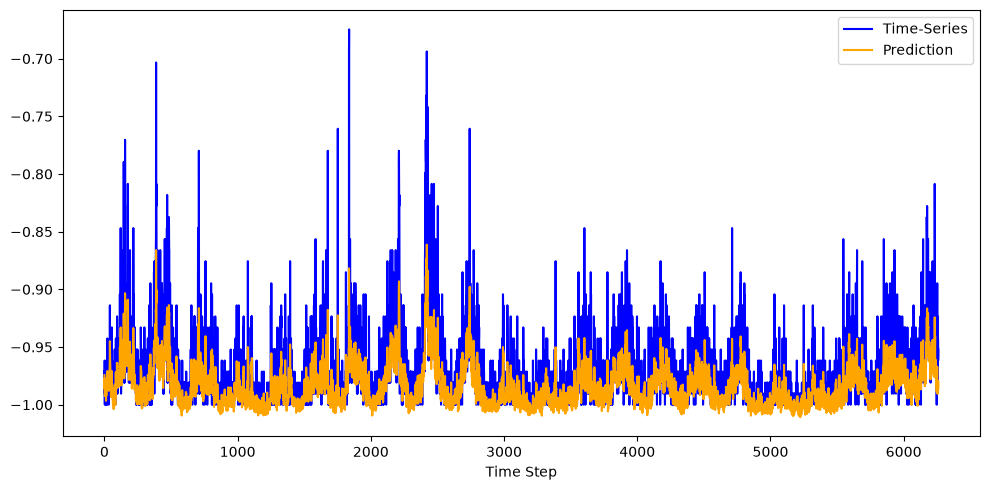

--------------
Twitter Signal 4
--------------
Epoch  25 | D Loss: 0.062709 | G Loss: -0.065689
Epoch  50 | D Loss: -0.018122 | G Loss: -0.242452
Epoch  75 | D Loss: 0.005599 | G Loss: -0.236548
Epoch 100 | D Loss: 0.006045 | G Loss: -0.172697
Epoch 125 | D Loss: 0.002740 | G Loss: -0.022306
Epoch 150 | D Loss: 0.002385 | G Loss: 0.006771
Epoch 175 | D Loss: 0.001188 | G Loss: -0.160915
Epoch 200 | D Loss: 0.001015 | G Loss: -0.164443
Epoch 225 | D Loss: -0.000426 | G Loss: -0.198787
Epoch 250 | D Loss: -0.000115 | G Loss: -0.089273
Epoch 275 | D Loss: 0.008584 | G Loss: -1.158425
Epoch 300 | D Loss: -0.004850 | G Loss: -0.486880
Epoch 325 | D Loss: -0.000995 | G Loss: -0.261354
Epoch 350 | D Loss: -0.003890 | G Loss: -0.244072
Epoch 375 | D Loss: -0.004585 | G Loss: -0.169720
Epoch 400 | D Loss: -0.001451 | G Loss: 0.179408
Epoch 425 | D Loss: -0.001551 | G Loss: 0.012627
Epoch 450 | D Loss: 0.004061 | G Loss: -1.192017
Epoch 475 | D Loss: -0.001868 | G Loss: -1.478091
Epoch 500 | D L

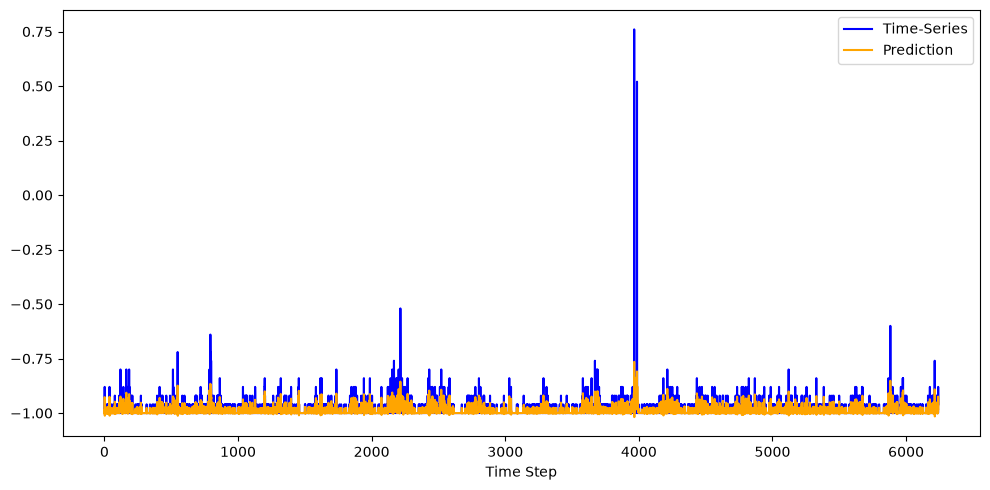

--------------
Twitter Signal 5
--------------
Epoch  25 | D Loss: 0.053950 | G Loss: 0.035881
Epoch  50 | D Loss: 0.209994 | G Loss: -0.185792
Epoch  75 | D Loss: 0.093278 | G Loss: 0.001852
Epoch 100 | D Loss: 0.109513 | G Loss: -0.185024
Epoch 125 | D Loss: 0.031014 | G Loss: -0.257651
Epoch 150 | D Loss: 0.037238 | G Loss: -0.352230
Epoch 175 | D Loss: 0.065581 | G Loss: -0.607063
Epoch 200 | D Loss: 0.062884 | G Loss: -0.524309
Epoch 225 | D Loss: 0.050068 | G Loss: -0.328199
Epoch 250 | D Loss: 0.041421 | G Loss: -0.235891
Epoch 275 | D Loss: -0.085316 | G Loss: -1.439834
Epoch 300 | D Loss: 0.091037 | G Loss: -0.677908
Epoch 325 | D Loss: 0.112937 | G Loss: -0.576591
Epoch 350 | D Loss: 0.169850 | G Loss: -0.909533
Epoch 375 | D Loss: 0.289239 | G Loss: -0.967907
Epoch 400 | D Loss: 0.573795 | G Loss: -1.904417
Epoch 425 | D Loss: 0.888069 | G Loss: -2.292597
Epoch 450 | D Loss: 1.145529 | G Loss: -2.050117
Epoch 475 | D Loss: 0.742398 | G Loss: -1.136561
Epoch 500 | D Loss: 0.6

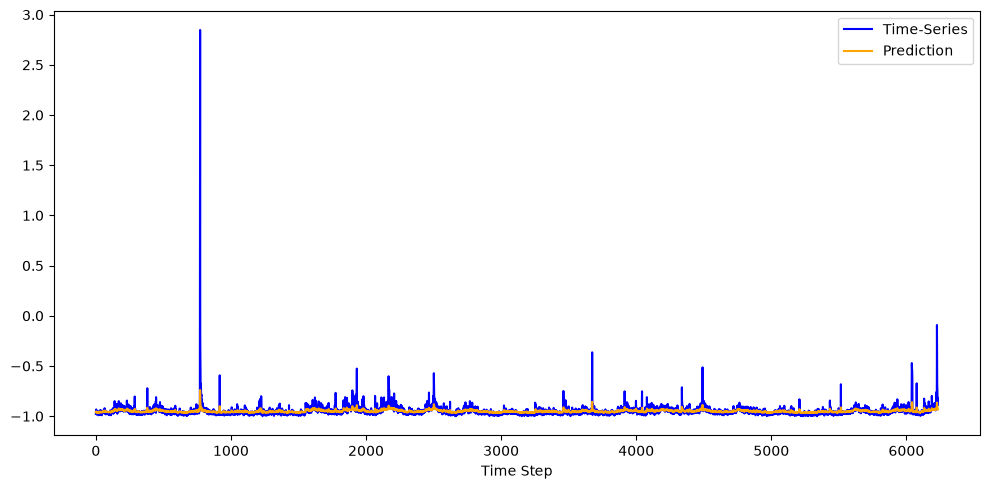

--------------
Twitter Signal 6
--------------
Epoch  25 | D Loss: 2.101909 | G Loss: -0.928634
Epoch  50 | D Loss: 0.592729 | G Loss: -0.392039
Epoch  75 | D Loss: 0.309596 | G Loss: -0.282744
Epoch 100 | D Loss: 0.075754 | G Loss: -0.030454
Epoch 125 | D Loss: 0.020095 | G Loss: 0.095916
Epoch 150 | D Loss: 0.026235 | G Loss: 0.282500
Epoch 175 | D Loss: 0.027101 | G Loss: 0.201149
Epoch 200 | D Loss: 0.019395 | G Loss: 0.272043
Epoch 225 | D Loss: 0.010042 | G Loss: 0.493758
Epoch 250 | D Loss: 0.009823 | G Loss: 0.525168
Epoch 275 | D Loss: 0.003037 | G Loss: 0.706027
Epoch 300 | D Loss: 0.007314 | G Loss: 0.165010
Epoch 325 | D Loss: 0.011992 | G Loss: 0.390267
Epoch 350 | D Loss: 0.003246 | G Loss: 0.185816
Epoch 375 | D Loss: 0.008106 | G Loss: 0.634862
Epoch 400 | D Loss: 0.014842 | G Loss: 0.922388
Epoch 425 | D Loss: -0.083397 | G Loss: 0.010478
Epoch 450 | D Loss: 0.014820 | G Loss: 1.566688
Epoch 475 | D Loss: 0.020674 | G Loss: 1.497982
Epoch 500 | D Loss: 0.030098 | G Los

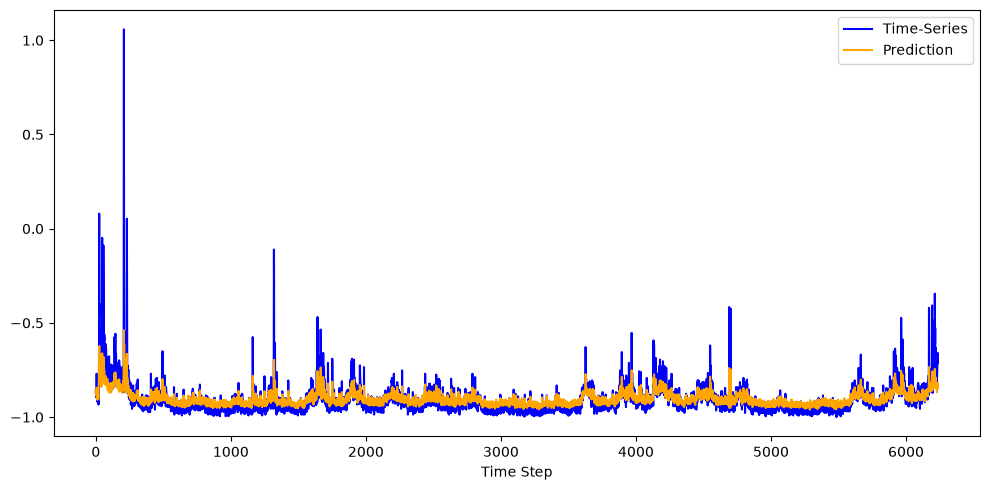

--------------
Twitter Signal 7
--------------
Epoch  25 | D Loss: 8.783406 | G Loss: -5.887895
Epoch  50 | D Loss: 0.388059 | G Loss: -0.687112
Epoch  75 | D Loss: 0.011742 | G Loss: 0.297531
Epoch 100 | D Loss: 0.169132 | G Loss: 0.128349
Epoch 125 | D Loss: 0.138050 | G Loss: -0.273009
Epoch 150 | D Loss: 0.095802 | G Loss: -0.279436
Epoch 175 | D Loss: 0.103075 | G Loss: -0.863481
Epoch 200 | D Loss: 0.142000 | G Loss: -1.029454
Epoch 225 | D Loss: 0.132922 | G Loss: -0.867380
Epoch 250 | D Loss: 0.102658 | G Loss: -0.662723
Epoch 275 | D Loss: 0.114994 | G Loss: -0.842521
Epoch 300 | D Loss: 0.073975 | G Loss: -1.073852
Epoch 325 | D Loss: 0.128224 | G Loss: -1.147836
Epoch 350 | D Loss: 0.188028 | G Loss: -0.875066
Epoch 375 | D Loss: 0.196175 | G Loss: -0.766873
Epoch 400 | D Loss: 0.224803 | G Loss: -0.887704
Epoch 425 | D Loss: 0.316797 | G Loss: -0.964500
Epoch 450 | D Loss: 0.437868 | G Loss: -1.077278
Epoch 475 | D Loss: 0.584291 | G Loss: -1.111432
Epoch 500 | D Loss: 0.96

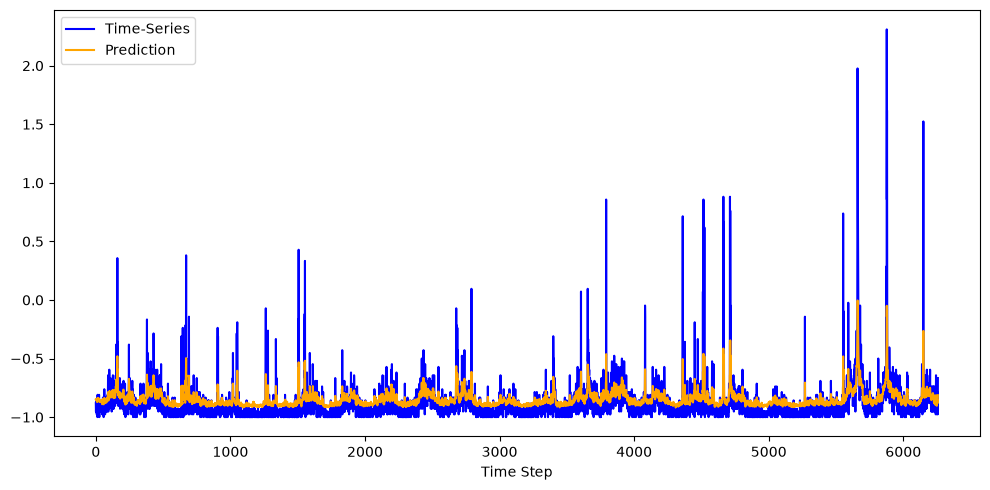

--------------
Twitter Signal 8
--------------
Epoch  25 | D Loss: 0.207913 | G Loss: -0.098597
Epoch  50 | D Loss: 0.081813 | G Loss: -0.134223
Epoch  75 | D Loss: 0.125652 | G Loss: -0.010186
Epoch 100 | D Loss: 0.127278 | G Loss: -0.353397
Epoch 125 | D Loss: 0.012574 | G Loss: -0.022324
Epoch 150 | D Loss: 0.012816 | G Loss: 0.279071
Epoch 175 | D Loss: 0.007975 | G Loss: 0.075902
Epoch 200 | D Loss: 0.004946 | G Loss: 0.236982
Epoch 225 | D Loss: 0.002811 | G Loss: 0.075208
Epoch 250 | D Loss: 0.004863 | G Loss: -0.072130
Epoch 275 | D Loss: 0.004576 | G Loss: -0.018230
Epoch 300 | D Loss: 0.004242 | G Loss: -0.016403
Epoch 325 | D Loss: 0.002006 | G Loss: -0.004438
Epoch 350 | D Loss: 0.003695 | G Loss: 0.081422
Epoch 375 | D Loss: 0.013536 | G Loss: -0.035609
Epoch 400 | D Loss: 0.043529 | G Loss: -0.113858
Epoch 425 | D Loss: 0.222543 | G Loss: -0.185639
Epoch 450 | D Loss: 0.087594 | G Loss: -0.076080
Epoch 475 | D Loss: 0.056013 | G Loss: 0.195788
Epoch 500 | D Loss: 0.035217

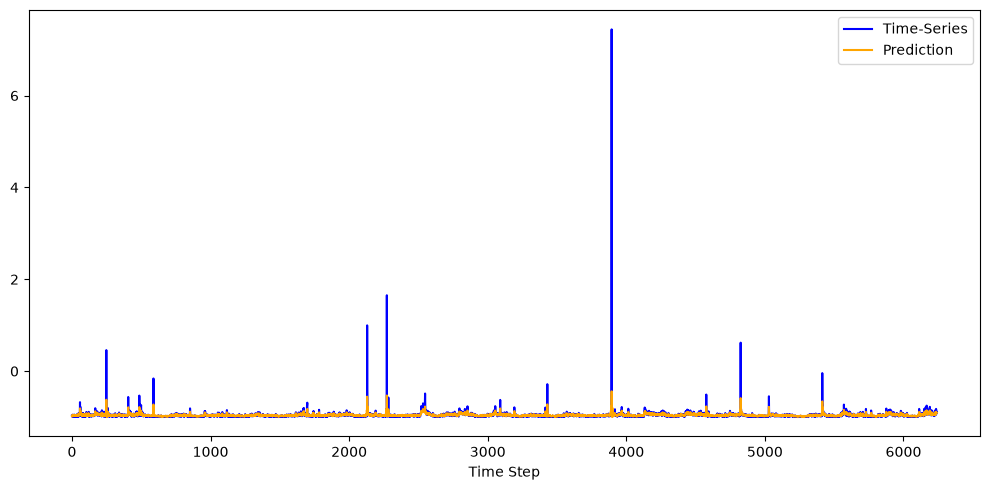

--------------
Twitter Signal 9
--------------
Epoch  25 | D Loss: -0.066379 | G Loss: 0.672123
Epoch  50 | D Loss: 0.469726 | G Loss: -0.366969
Epoch  75 | D Loss: -0.008031 | G Loss: 0.052512
Epoch 100 | D Loss: -0.035198 | G Loss: 0.002521
Epoch 125 | D Loss: 0.029736 | G Loss: -0.030965
Epoch 150 | D Loss: 0.022719 | G Loss: 0.232967
Epoch 175 | D Loss: 0.039007 | G Loss: 0.124722
Epoch 200 | D Loss: 0.017795 | G Loss: 0.197874
Epoch 225 | D Loss: -3.803357 | G Loss: 0.217842
Epoch 250 | D Loss: 0.019012 | G Loss: 0.458618
Epoch 275 | D Loss: 0.026026 | G Loss: 0.036621
Epoch 300 | D Loss: 0.024859 | G Loss: 0.377481
Epoch 325 | D Loss: 0.010059 | G Loss: 0.844121
Epoch 350 | D Loss: 0.008318 | G Loss: 0.658002
Epoch 375 | D Loss: 0.021287 | G Loss: 1.503046
Epoch 400 | D Loss: 0.104338 | G Loss: 1.198451
Epoch 425 | D Loss: 0.093618 | G Loss: 1.340331
Epoch 450 | D Loss: 0.089066 | G Loss: 0.863759
Epoch 475 | D Loss: 0.109958 | G Loss: 1.009621
Epoch 500 | D Loss: 0.040746 | G Lo

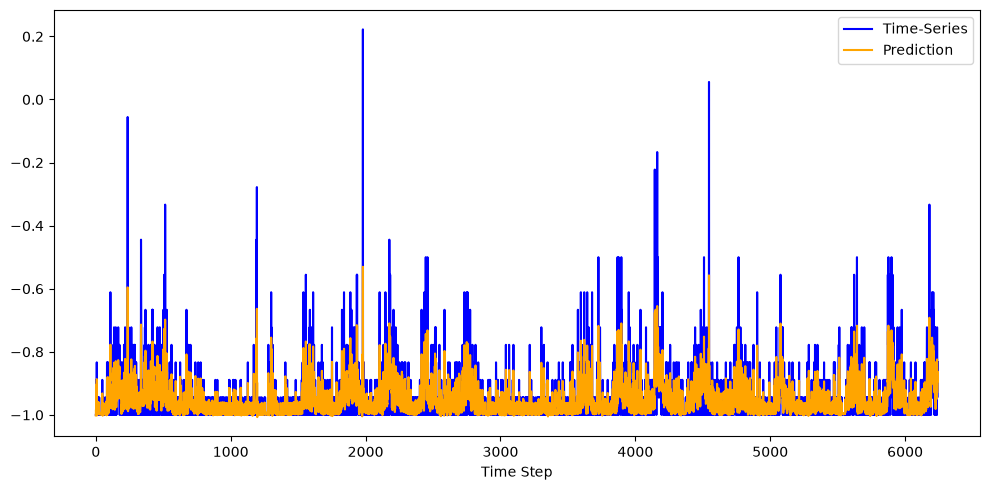

--------------
Twitter Signal 10
--------------
Epoch  25 | D Loss: 2.833686 | G Loss: -1.991815
Epoch  50 | D Loss: -0.164408 | G Loss: 0.340126
Epoch  75 | D Loss: 0.234535 | G Loss: -0.151683
Epoch 100 | D Loss: 0.020365 | G Loss: 0.118657
Epoch 125 | D Loss: 0.023559 | G Loss: 0.457003
Epoch 150 | D Loss: 0.000505 | G Loss: 0.449603
Epoch 175 | D Loss: 0.042892 | G Loss: -0.024864
Epoch 200 | D Loss: 0.073515 | G Loss: -0.070971
Epoch 225 | D Loss: -0.013763 | G Loss: 0.840117
Epoch 250 | D Loss: 0.015047 | G Loss: 0.200067
Epoch 275 | D Loss: 0.836696 | G Loss: -1.802728
Epoch 300 | D Loss: 0.080188 | G Loss: -0.424176
Epoch 325 | D Loss: 0.041381 | G Loss: 0.465825
Epoch 350 | D Loss: 0.057155 | G Loss: -1.077027
Epoch 375 | D Loss: 0.010893 | G Loss: -0.117442
Epoch 400 | D Loss: -3.540597 | G Loss: 2.467101
Epoch 425 | D Loss: 0.031231 | G Loss: -0.457759
Epoch 450 | D Loss: -0.010939 | G Loss: 0.314451
Epoch 475 | D Loss: 0.077521 | G Loss: -0.657614
Epoch 500 | D Loss: 0.0726

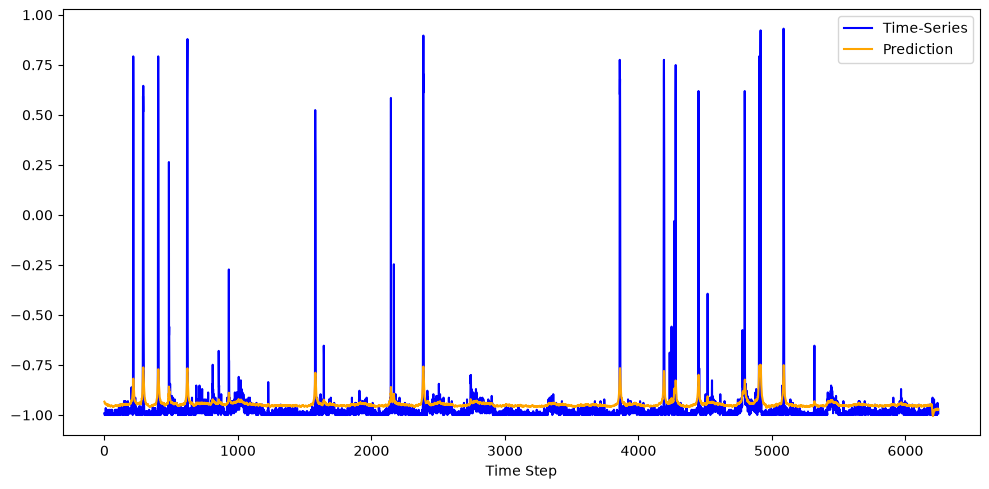

------------------
Twitter Metrics
------------------
[point] Precision: 0.098 | Recall: 0.550 | F1: 0.164
[area] Precision: 0.128 | Recall: 0.650 | F1: 0.209


In [12]:
total_metrics = {name: np.zeros(3) for (name, _) in NAB_HYPERPARAMS["rec_error_funcs"]}

for i, twitter_signal in enumerate(twitter_signals):
    X = twitter_signal['value'].to_numpy()
    # expand from shape (T, ) to (T, 1)  
    X = np.expand_dims(X, axis=1)
    y = twitter_signal['is_anomaly'].to_numpy()

    print("--------------")
    print(f"Twitter Signal {i + 1}")
    print("--------------")
    
    metrics = run_pipeline(X, y, **NAB_HYPERPARAMS)

    for key in total_metrics:
        total_metrics[key] += np.array(metrics[key])

print("------------------")
print("Twitter Metrics")
print("------------------")

for key in total_metrics:
    total_metrics[key] = total_metrics[key] / len(twitter_signals)
    print(f"[{key}] Precision: {total_metrics[key][0]:.3f} | Recall: {total_metrics[key][1]:.3f} | F1: {total_metrics[key][2]:.3f}")